# Exploratory Data Analysis (EDA)
# Digital Lifestyle Benchmark Dataset — Silver Layer
# ============================================================
# This script performs a full EDA on the Silver Layer dataset
# across five analytical axes:
#
#   1. Univariate Analysis   — distribution of each column
#   2. Bivariate Analysis    — relationships between columns
#   3. Group Analysis        — comparisons across categories
#   4. Outlier Detection     — IQR-based detection + boxplots
#   5. High Risk Analysis    — deep dive into high_risk_flag=1
#
# All plots are saved under EDA_Output/.
# A single summary report (eda_summary_report.csv) is also saved.
# ============================================================

## ── 1. Import Required Libraries ────────────────────────────


In [ ]:
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

## ── 2. Configuration ─────────────────────────────────────────

In [ ]:
SILVER_FILE_PATH = "Silver_Layer/Digital_Lifestyle_Benchmark_Silver.csv"

EDA_FOLDER = "EDA_Output"
os.makedirs(EDA_FOLDER, exist_ok=True)

# Global plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGURE_DPI = 150

print(f"EDA Output folder ready at: ./{EDA_FOLDER}/")


def save_fig(filename: str) -> None:
    """Save current figure to EDA_Output folder and close it."""
    plt.tight_layout()
    plt.savefig(os.path.join(EDA_FOLDER, filename), dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {filename}")

EDA Output folder ready at: ./EDA_Output/


## ── 3. Load Silver Dataset ───────────────────────────────────

In [ ]:
df = pd.read_csv(SILVER_FILE_PATH)

print(f"\nSilver dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


Silver dataset loaded: 100,000 rows × 30 columns


## ── 4. Column Definitions ────────────────────────────────────

In [ ]:
NUMERIC_COLS = [
    "age",
    "device_hours_per_day",
    "phone_unlocks",
    "notifications_per_day",
    "social_media_mins",
    "study_mins",
    "physical_activity_days",
    "sleep_hours",
    "sleep_quality",
    "anxiety_score",
    "depression_score",
    "stress_level",
    "happiness_score",
    "focus_score",
    "productivity_score",
    "digital_dependence_score",
    "digital_wellness_score",
]

CATEGORICAL_COLS = [
    "gender",
    "region",
    "income_level",
    "education_level",
    "daily_role",
    "device_type",
    "age_group",
    "screen_time_category",
    "sleep_category",
    "mental_health_risk",
    "productivity_category",
]

AGE_ORDER         = ["Teen", "Young Adult", "Adult", "Mid Age", "Senior"]
INCOME_ORDER      = ["Low", "Lower-Mid", "Upper-Mid", "High"]
SCREEN_ORDER      = ["Low", "Moderate", "High", "Very High"]
SLEEP_CAT_ORDER   = ["Poor Sleep", "Average Sleep", "Healthy Sleep", "Oversleep"]
MH_ORDER          = ["Low", "Medium", "High"]
PROD_ORDER        = ["Low", "Average", "Good", "Excellent"]

## SECTION 1 — UNIVARIATE ANALYSIS


SECTION 1 — UNIVARIATE ANALYSIS

[1A] Descriptive Statistics:
                            mean     std    min     50%      max  skewness
age                        30.96   12.58  13.00   28.00    65.00      0.85
device_hours_per_day        7.33    3.23   0.18    6.76    17.44      0.71
phone_unlocks             144.60   68.73   5.00  134.00   391.00      0.63
notifications_per_day     335.59  239.28  10.00  269.00  1232.00      1.64
social_media_mins         156.10  134.68   0.00  116.00   659.00      1.57
study_mins                108.33   79.41   0.00  102.00   423.00      0.49
physical_activity_days      3.36    1.87   0.00    3.00     7.00      0.07
sleep_hours                 7.30    1.31   2.70    7.30    11.30     -0.17
sleep_quality               2.70    1.10   1.00    2.90     5.00      0.04
anxiety_score               7.20    5.08   0.00    6.00    27.30      1.56
depression_score            8.84    5.73   0.00    8.00    27.00      0.48
stress_level                5.08    3

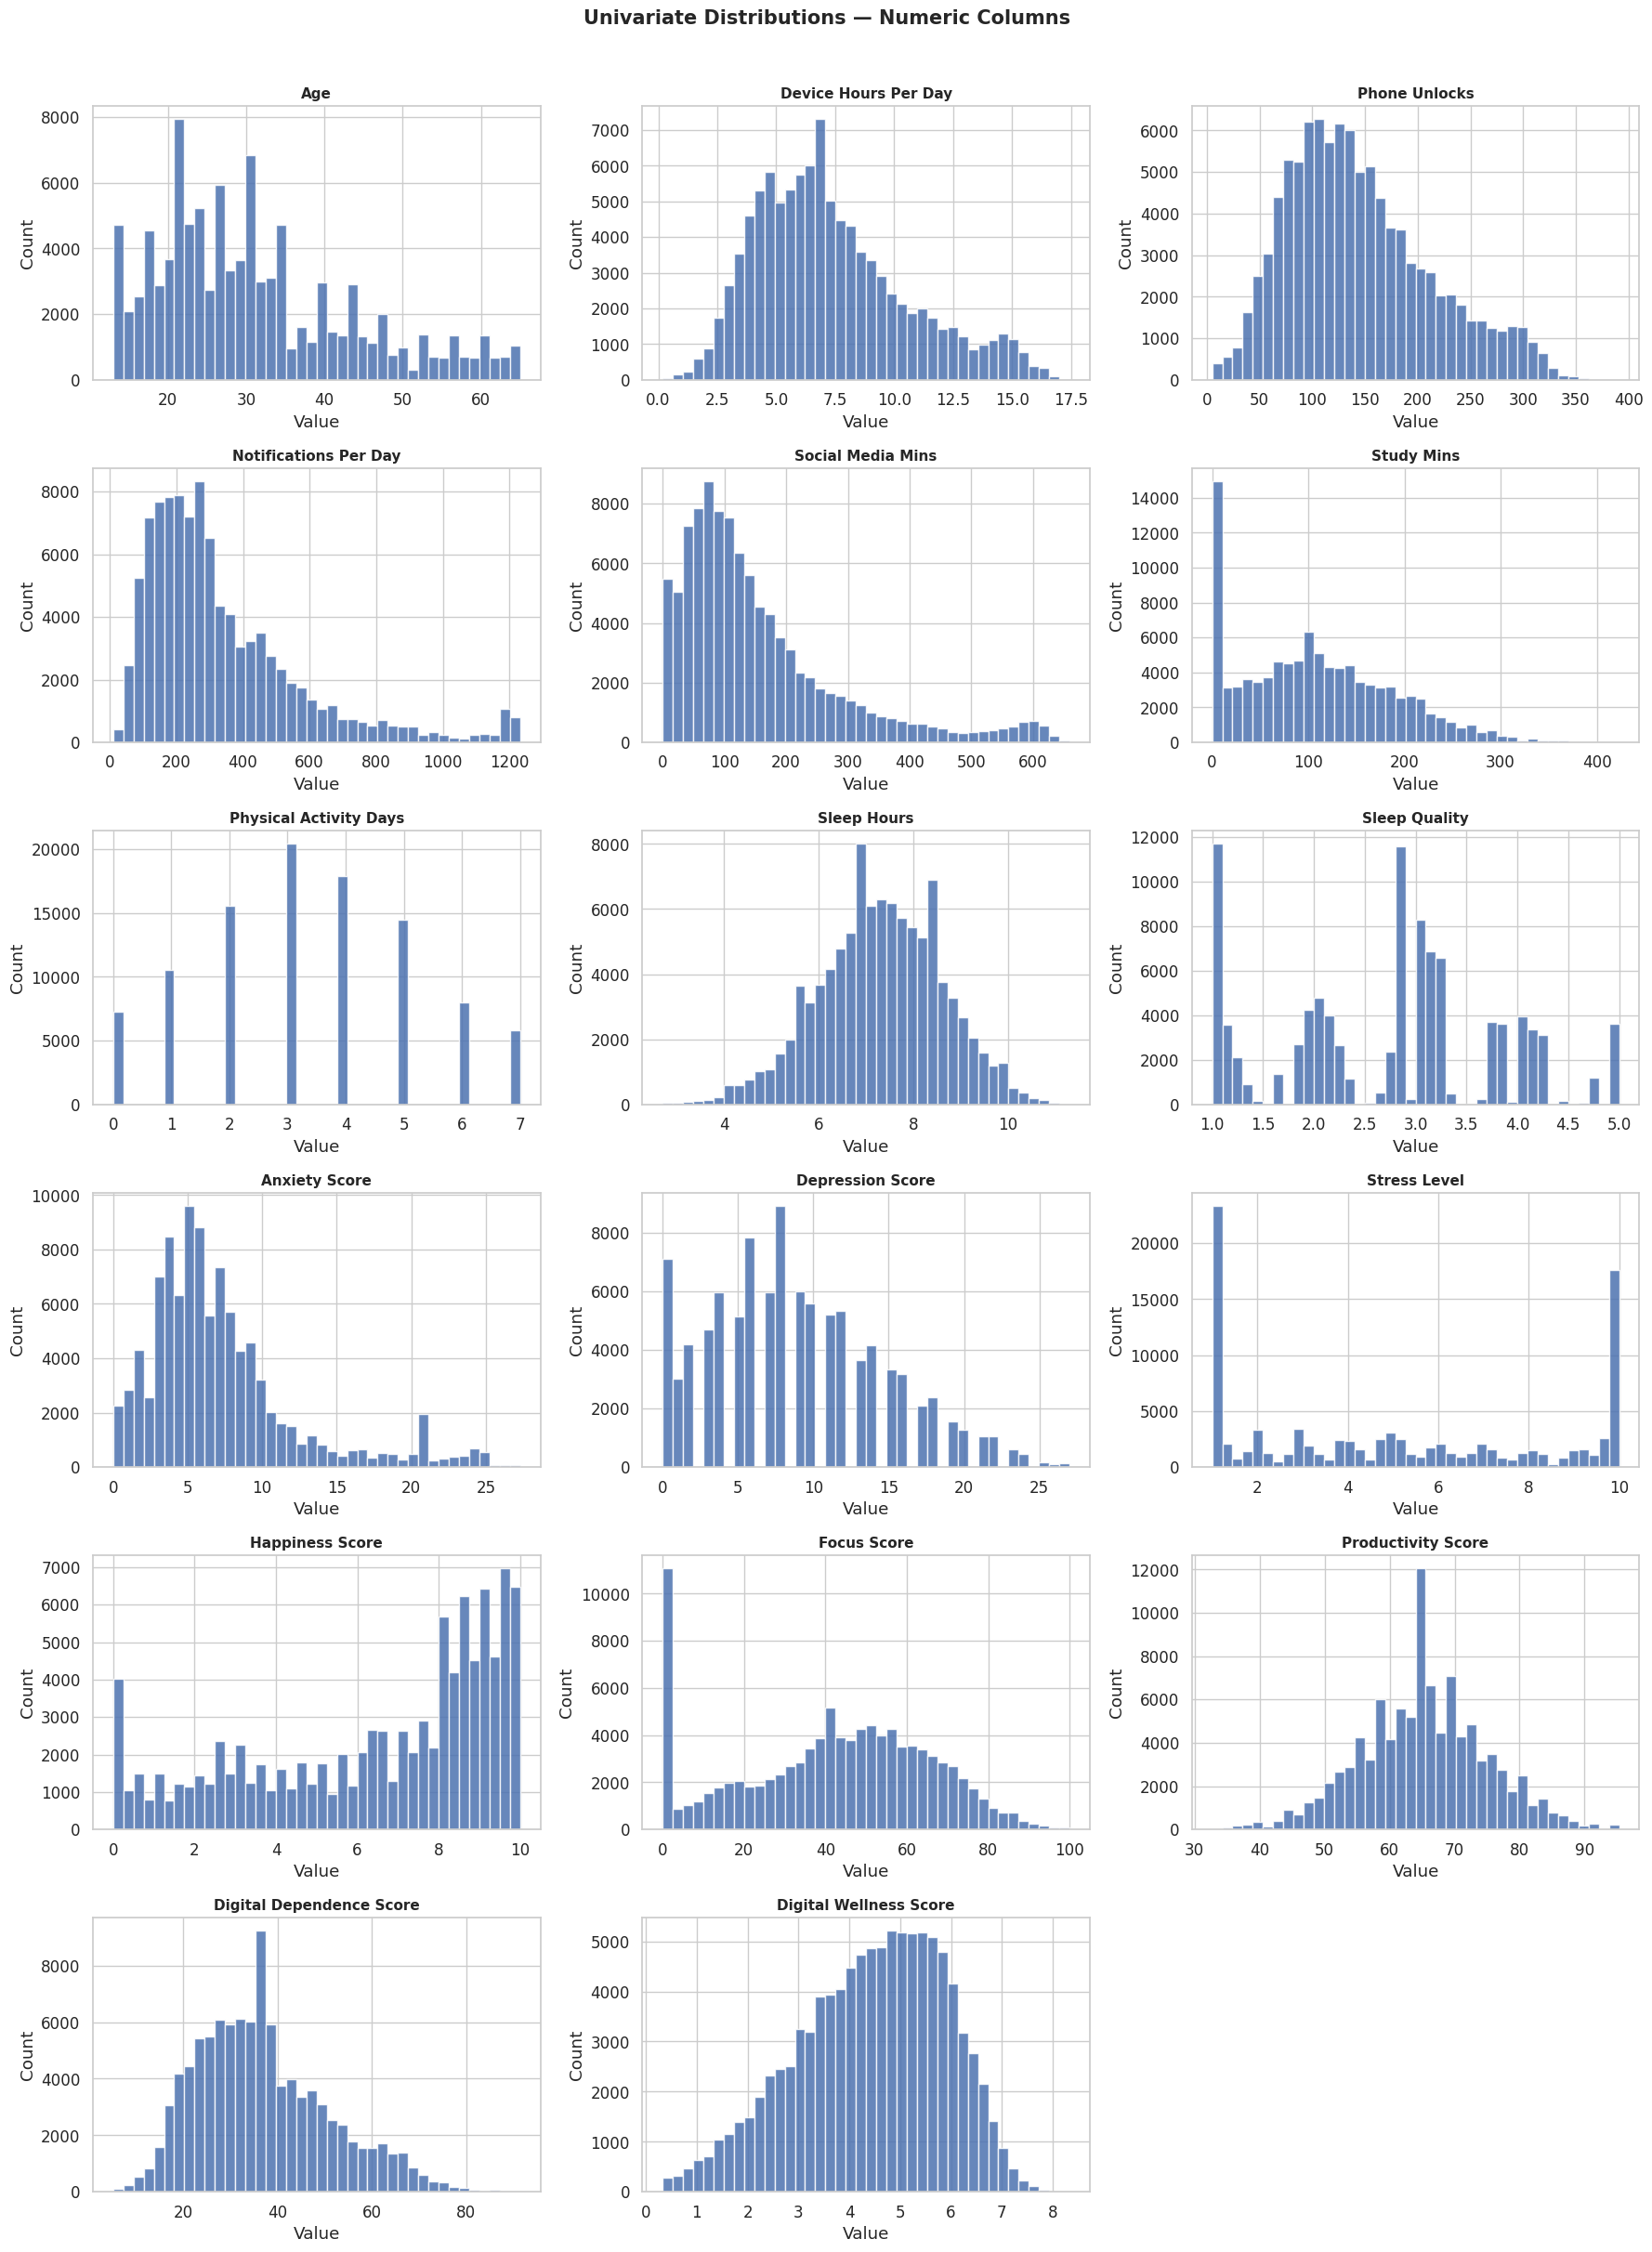


[1C] Plotting bar charts for all categorical columns...


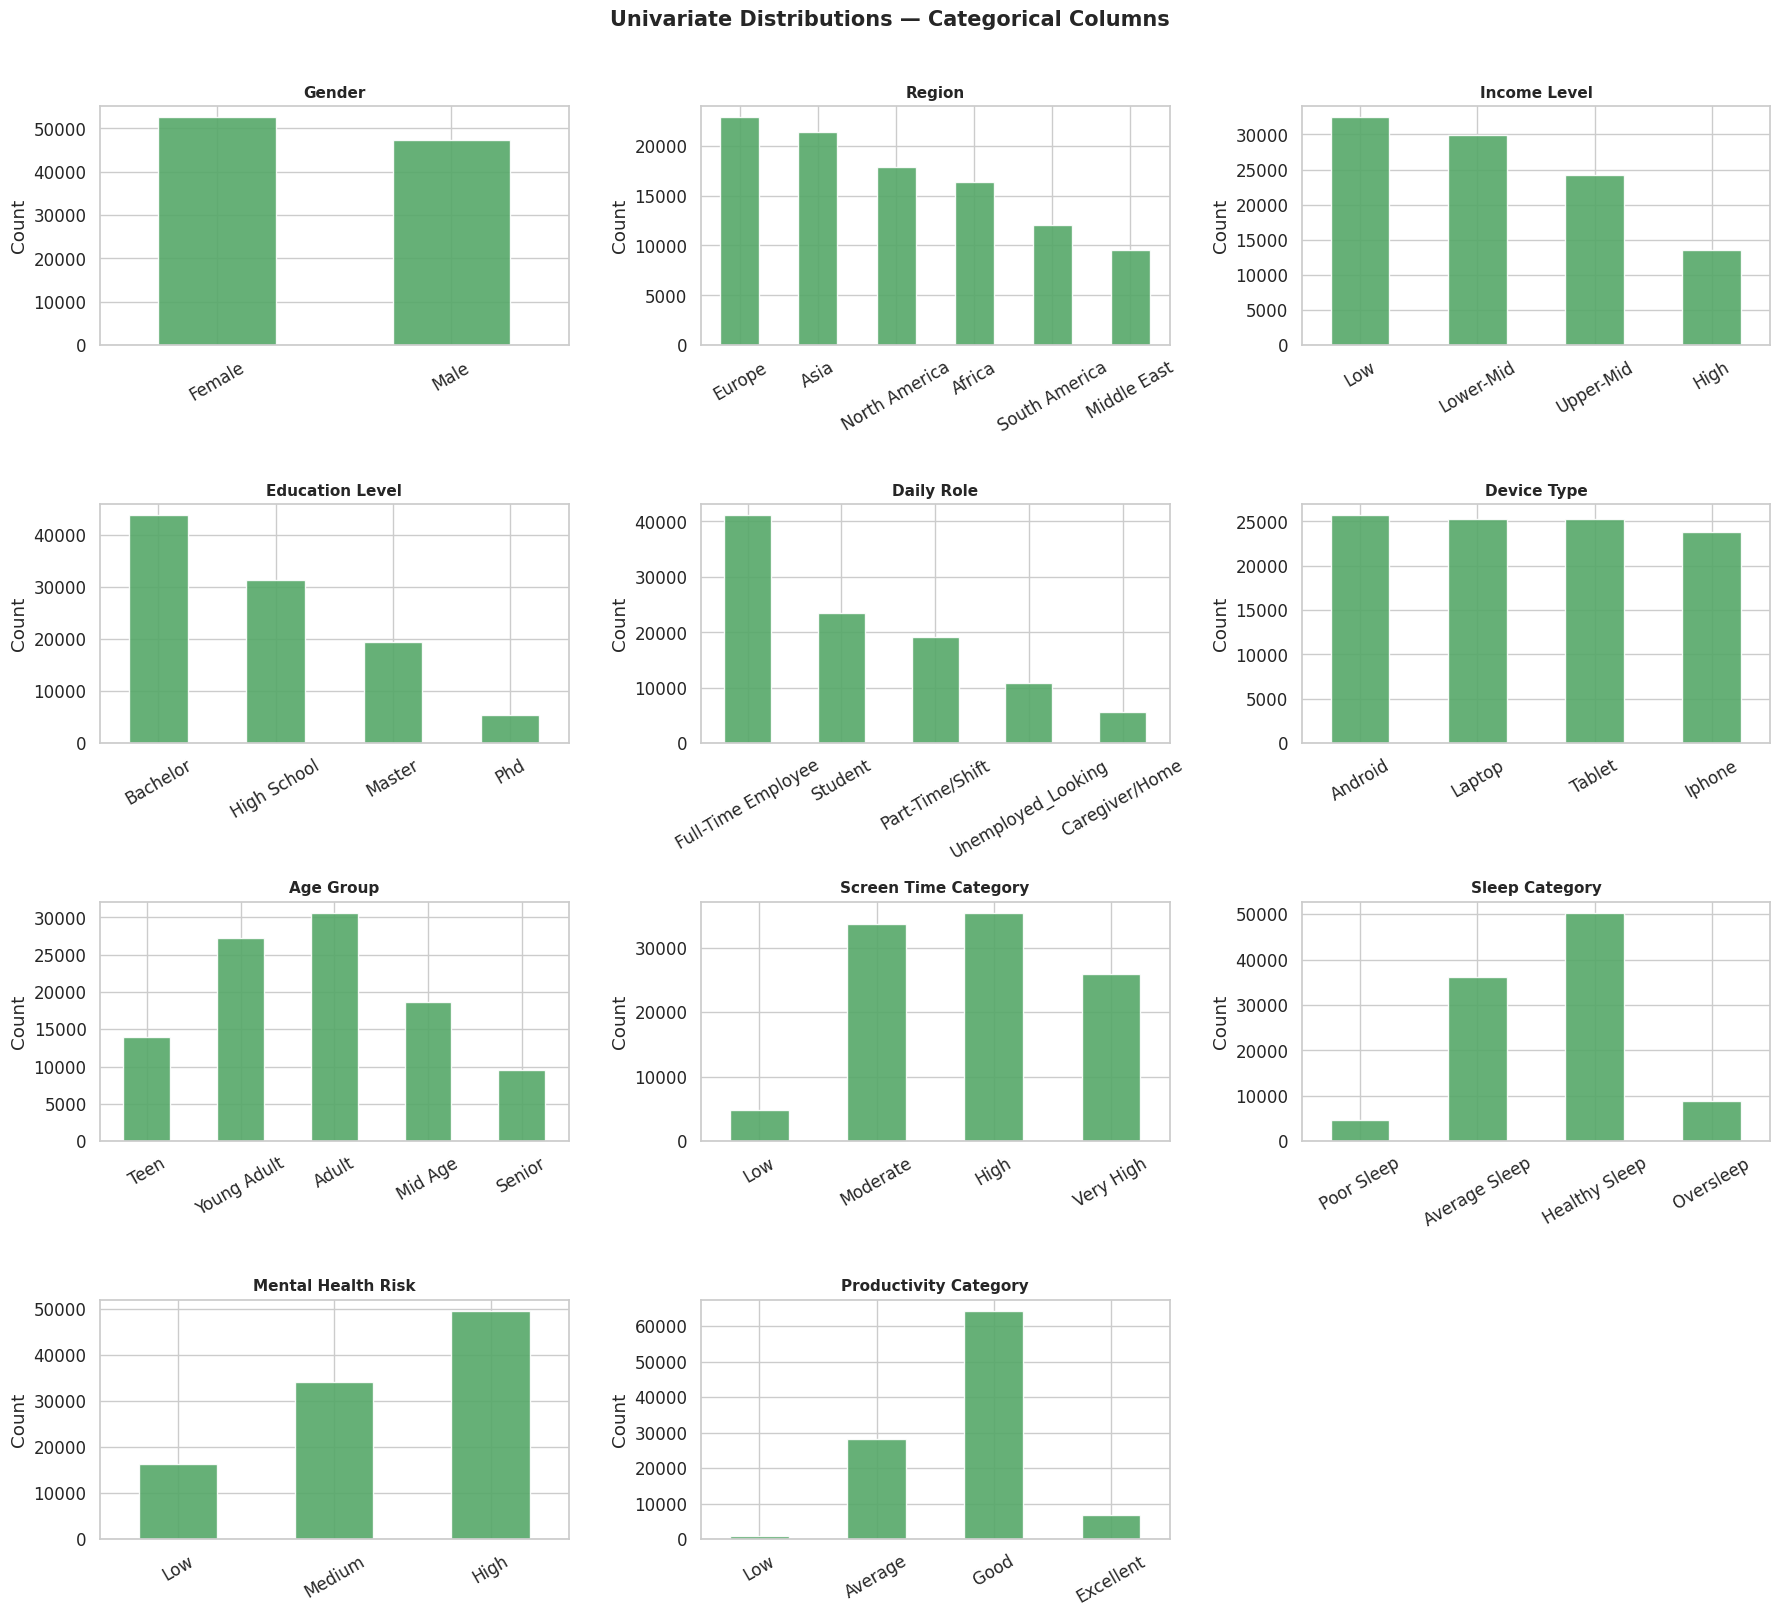

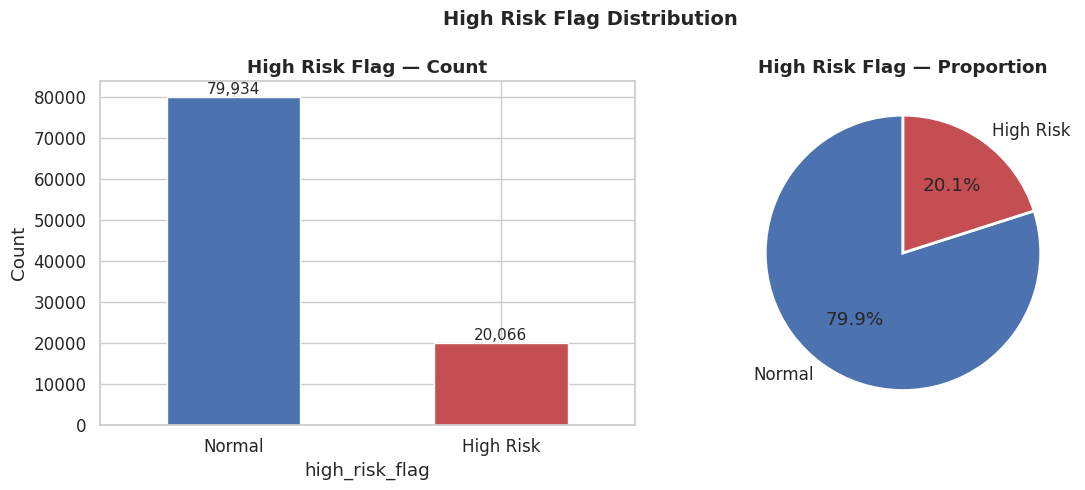

In [ ]:
print("\n" + "=" * 50)
print("SECTION 1 — UNIVARIATE ANALYSIS")
print("=" * 50)

# ── 1A. Descriptive Statistics ───────────────────────────────

desc = df[NUMERIC_COLS].describe().T
desc["skewness"] = df[NUMERIC_COLS].skew().round(2)
desc["kurtosis"] = df[NUMERIC_COLS].kurt().round(2)
desc = desc.round(2)

print("\n[1A] Descriptive Statistics:")
print(desc[["mean", "std", "min", "50%", "max", "skewness"]].to_string())


# ── 1B. Histograms — all numeric columns ─────────────────────

print("\n[1B] Plotting histograms for all numeric columns...")

n_cols = 3
n_rows = int(np.ceil(len(NUMERIC_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].hist(
        df[col].dropna(),
        bins=40,
        color="#4C72B0",
        edgecolor="white",
        alpha=0.85
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Univariate Distributions — Numeric Columns",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


# ── 1C. Bar Charts — all categorical columns ─────────────────

print("\n[1C] Plotting bar charts for all categorical columns...")

ORDER_MAP = {
    "age_group": AGE_ORDER,
    "income_level": INCOME_ORDER,
    "screen_time_category": SCREEN_ORDER,
    "sleep_category": SLEEP_CAT_ORDER,
    "mental_health_risk": MH_ORDER,
    "productivity_category": PROD_ORDER,
}

n_cols_cat = 3
n_rows_cat = int(np.ceil(len(CATEGORICAL_COLS) / n_cols_cat))

fig, axes = plt.subplots(
    n_rows_cat,
    n_cols_cat,
    figsize=(18, n_rows_cat * 4)
)

axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    order = ORDER_MAP.get(col)

    counts = df[col].value_counts()

    if order:
        counts = counts.reindex(
            [o for o in order if o in counts.index]
        )

    counts.plot(
        kind="bar",
        ax=axes[i],
        color="#55A868",
        edgecolor="white",
        alpha=0.9
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Univariate Distributions — Categorical Columns",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


# ── 1D. High Risk Flag Distribution ─────────────────────────

high_risk_counts = (
    df["high_risk_flag"]
    .value_counts()
    .rename({0: "Normal", 1: "High Risk"})
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

high_risk_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#C44E52"],
    edgecolor="white"
)

axes[0].set_title(
    "High Risk Flag — Count",
    fontweight="bold"
)

axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

for bar in axes[0].patches:
    axes[0].annotate(
        f"{int(bar.get_height()):,}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=11
    )

axes[1].pie(
    high_risk_counts,
    labels=high_risk_counts.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#C44E52"],
    startangle=90,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

axes[1].set_title(
    "High Risk Flag — Proportion",
    fontweight="bold"
)

fig.suptitle(
    "High Risk Flag Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## SECTION 2 — BIVARIATE ANALYSIS


SECTION 2 — BIVARIATE ANALYSIS

[2A] Plotting correlation matrix...


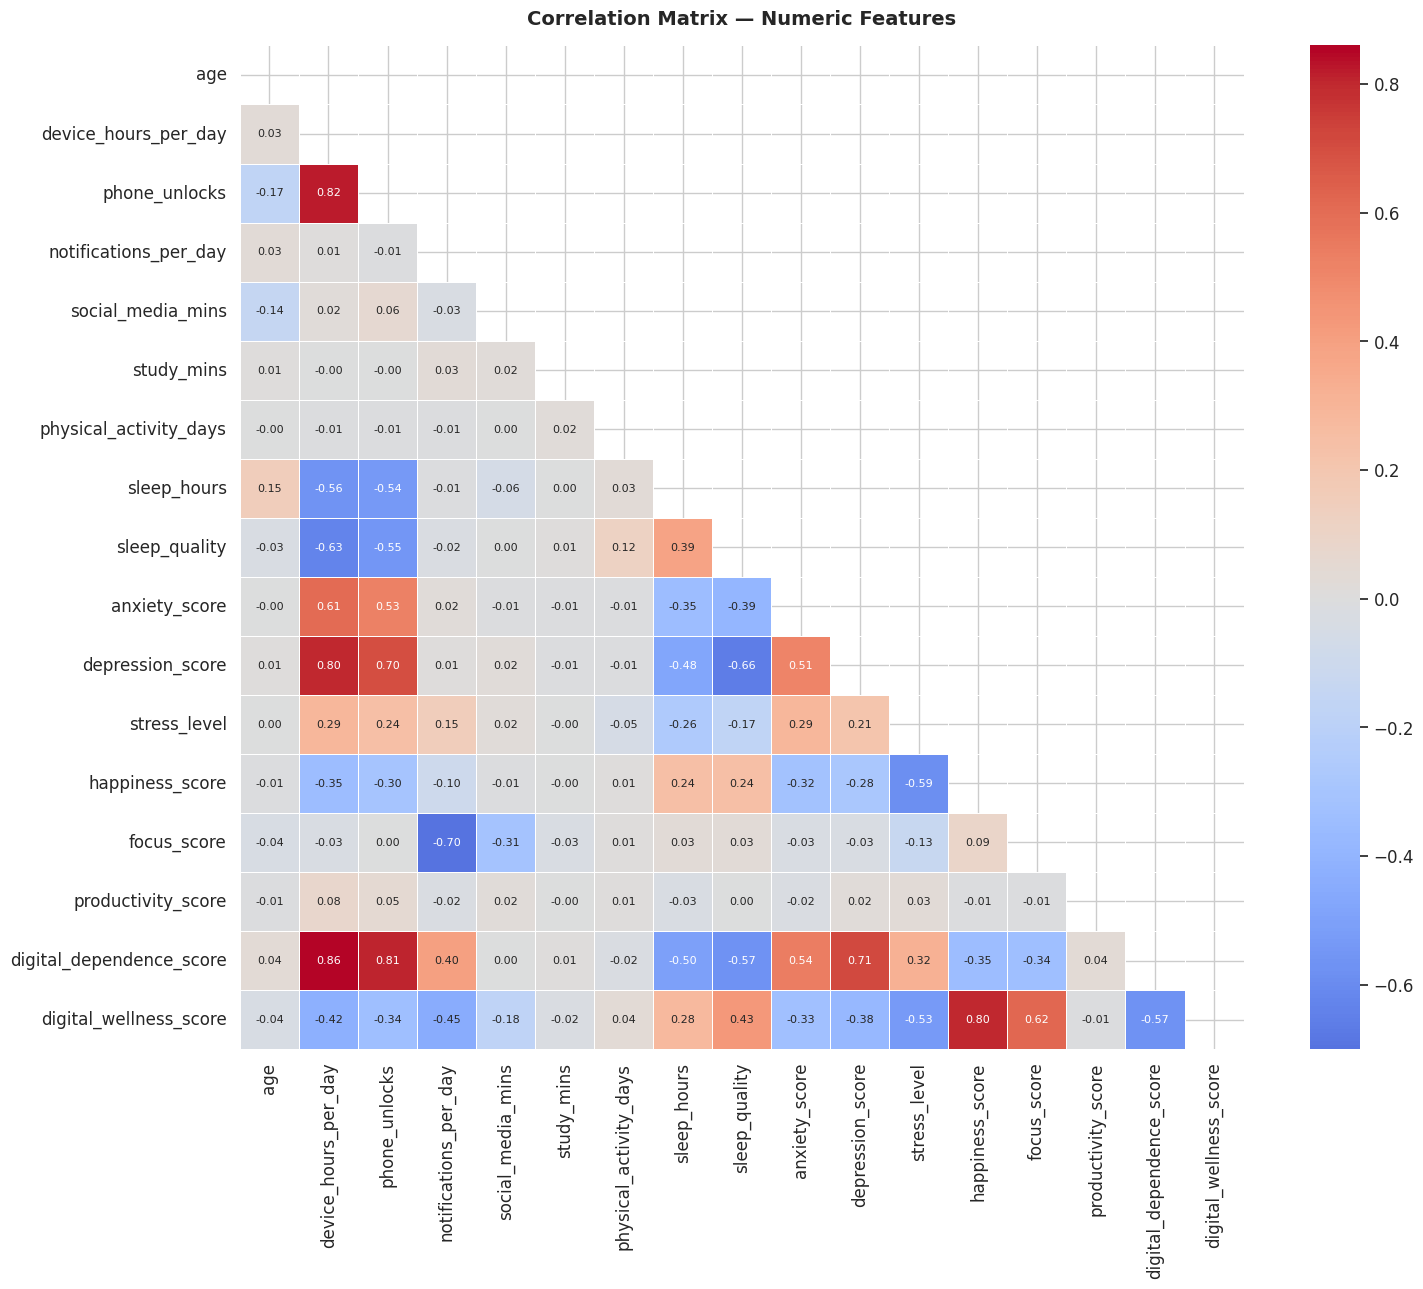


[2B] Plotting key scatter plots...


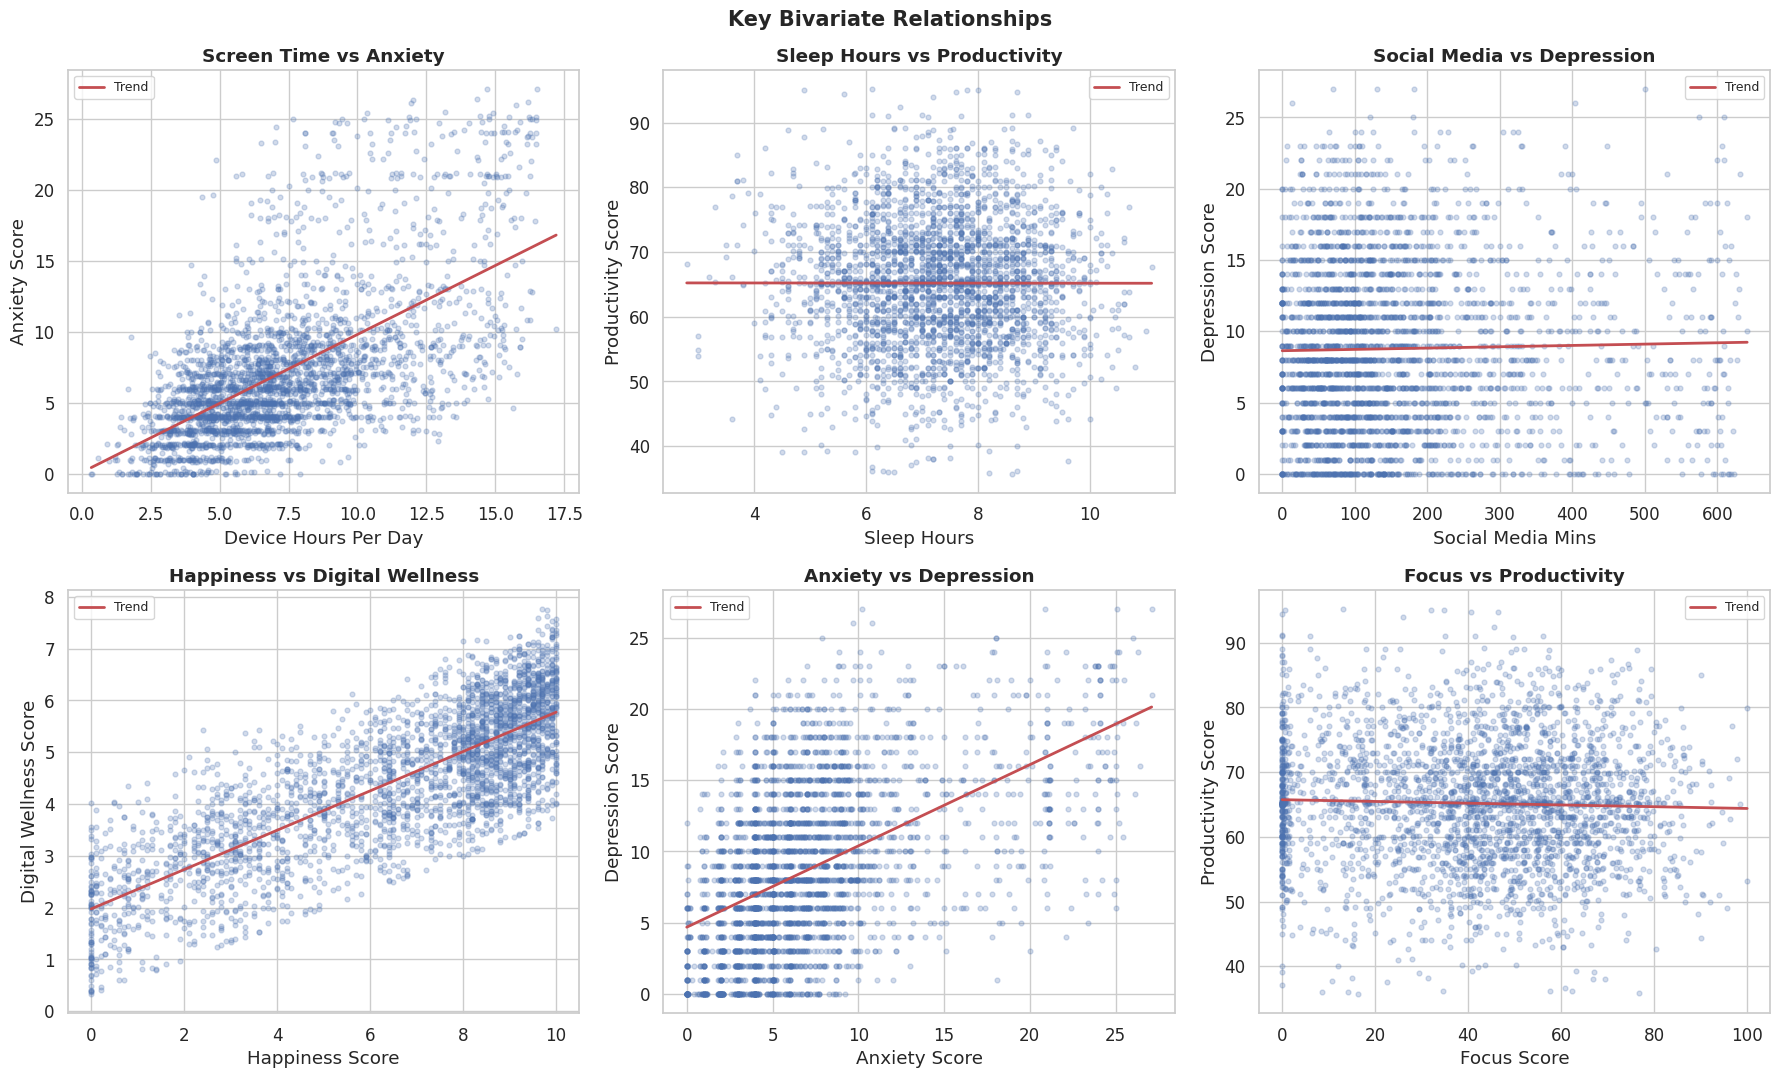


[2C] Plotting violin plots — numeric vs high_risk_flag...


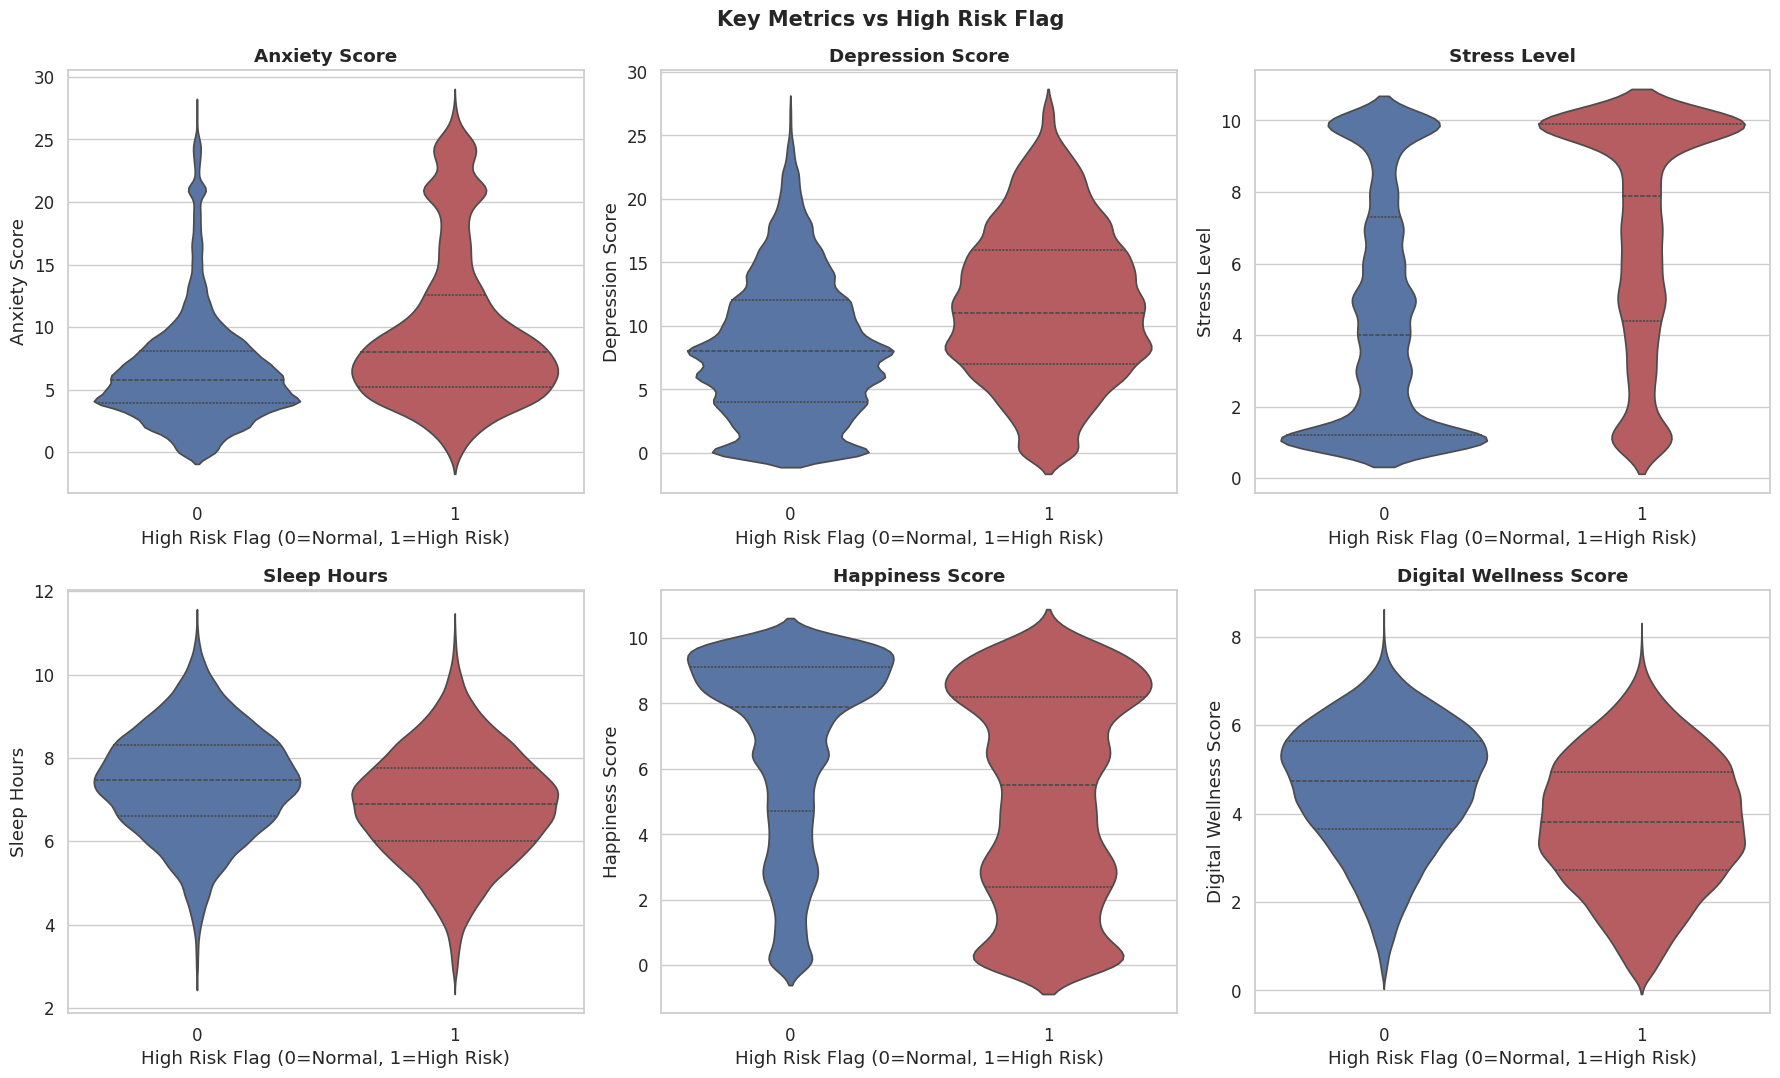


[2D] Top correlations with high_risk_flag...

Top Correlations with High Risk Flag:

device_hours_per_day        0.274
digital_dependence_score    0.271
stress_level                0.269
anxiety_score               0.260
depression_score            0.249
phone_unlocks               0.236
digital_wellness_score     -0.218
happiness_score            -0.208
sleep_quality              -0.180
sleep_hours                -0.176
notifications_per_day       0.062
focus_score                -0.053
physical_activity_days     -0.013
productivity_score          0.010
social_media_mins           0.007
study_mins                 -0.005
age                         0.004


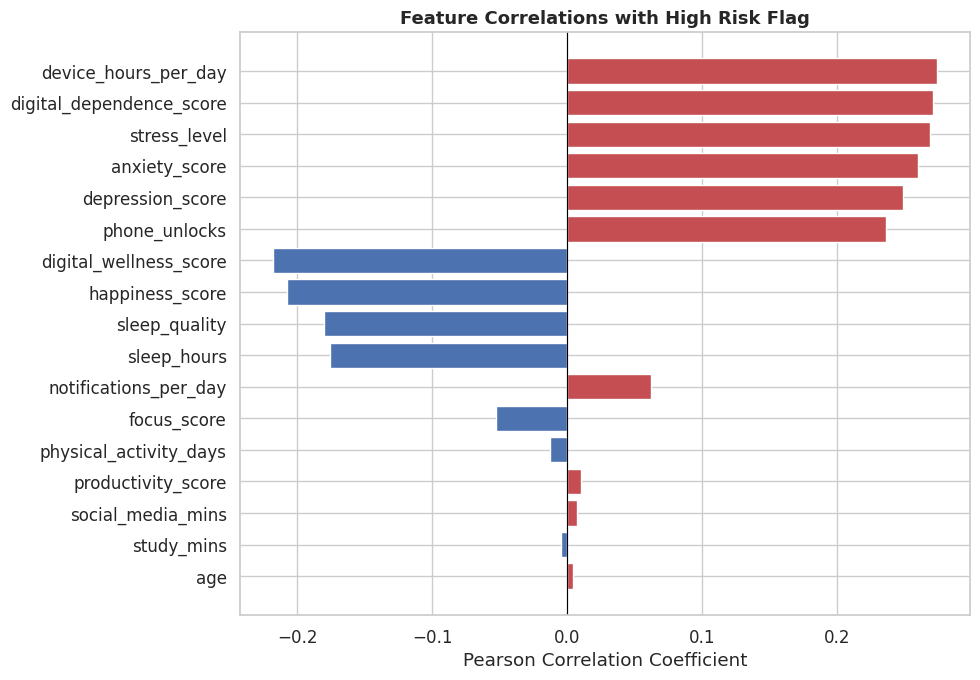

In [ ]:
print("\n" + "=" * 50)
print("SECTION 2 — BIVARIATE ANALYSIS")
print("=" * 50)

# ── 2A. Correlation Matrix ───────────────────────────────────

print("\n[2A] Plotting correlation matrix...")

corr = df[NUMERIC_COLS].corr().round(2)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 8},
)

ax.set_title(
    "Correlation Matrix — Numeric Features",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()


# ── 2B. Key Scatter Plots ────────────────────────────────────

print("\n[2B] Plotting key scatter plots...")

SCATTER_PAIRS = [
    ("device_hours_per_day", "anxiety_score",          "Screen Time vs Anxiety"),
    ("sleep_hours",          "productivity_score",     "Sleep Hours vs Productivity"),
    ("social_media_mins",    "depression_score",       "Social Media vs Depression"),
    ("happiness_score",      "digital_wellness_score", "Happiness vs Digital Wellness"),
    ("anxiety_score",        "depression_score",       "Anxiety vs Depression"),
    ("focus_score",          "productivity_score",     "Focus vs Productivity"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

sample = df.sample(min(3000, len(df)), random_state=42)

for i, (x_col, y_col, title) in enumerate(SCATTER_PAIRS):

    axes[i].scatter(
        sample[x_col],
        sample[y_col],
        alpha=0.25,
        s=12,
        color="#4C72B0"
    )

    z = np.polyfit(
        sample[x_col].dropna(),
        sample[y_col].dropna(),
        1
    )

    p = np.poly1d(z)

    x_l = np.linspace(
        sample[x_col].min(),
        sample[x_col].max(),
        200
    )

    axes[i].plot(
        x_l,
        p(x_l),
        color="#C44E52",
        linewidth=2,
        label="Trend"
    )

    axes[i].set_title(title, fontweight="bold")
    axes[i].set_xlabel(x_col.replace("_", " ").title())
    axes[i].set_ylabel(y_col.replace("_", " ").title())
    axes[i].legend(fontsize=9)

fig.suptitle(
    "Key Bivariate Relationships",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ── 2C. Numeric vs High Risk Flag (Violin Plots) ─────────────

print("\n[2C] Plotting violin plots — numeric vs high_risk_flag...")

VIOLIN_COLS = [
    "anxiety_score",
    "depression_score",
    "stress_level",
    "sleep_hours",
    "happiness_score",
    "digital_wellness_score",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(VIOLIN_COLS):

    sns.violinplot(
        data=df,
        x="high_risk_flag",
        y=col,
        palette=["#4C72B0", "#C44E52"],
        order=[0, 1],
        ax=axes[i],
        inner="quartile",
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontweight="bold"
    )

    axes[i].set_xlabel(
        "High Risk Flag (0=Normal, 1=High Risk)"
    )

    axes[i].set_ylabel(
        col.replace("_", " ").title()
    )

fig.suptitle(
    "Key Metrics vs High Risk Flag",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ── 2D. Top Correlations with High Risk Flag ─────────────────

print("\n[2D] Top correlations with high_risk_flag...")

hr_corr = (
    df[NUMERIC_COLS + ["high_risk_flag"]]
    .corr()["high_risk_flag"]
    .drop("high_risk_flag")
    .sort_values(key=abs, ascending=False)
    .round(3)
)

print("\nTop Correlations with High Risk Flag:\n")
print(hr_corr.to_string())

fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    "#C44E52" if v > 0 else "#4C72B0"
    for v in hr_corr.values
]

ax.barh(
    hr_corr.index[::-1],
    hr_corr.values[::-1],
    color=colors[::-1],
    edgecolor="white"
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Feature Correlations with High Risk Flag",
    fontweight="bold",
    fontsize=13
)

ax.set_xlabel(
    "Pearson Correlation Coefficient"
)

plt.tight_layout()
plt.show()

## SECTION 3 — GROUP ANALYSIS


SECTION 3 — GROUP ANALYSIS

[3A] Wellness & Mental Health by Region...

Average Metrics by Region:
               digital_wellness_score  anxiety_score  depression_score  \
region                                                                   
North America                    4.44           7.17              8.83   
South America                    4.44           7.19              8.87   
Europe                           4.42           7.24              8.83   
Africa                           4.42           6.98              8.86   
Asia                             4.41           7.36              8.79   
Middle East                      4.41           7.23              8.95   

               happiness_score  productivity_score  
region                                              
North America             6.50               65.43  
South America             6.44               65.25  
Europe                    6.33               65.26  
Africa                    6.43            

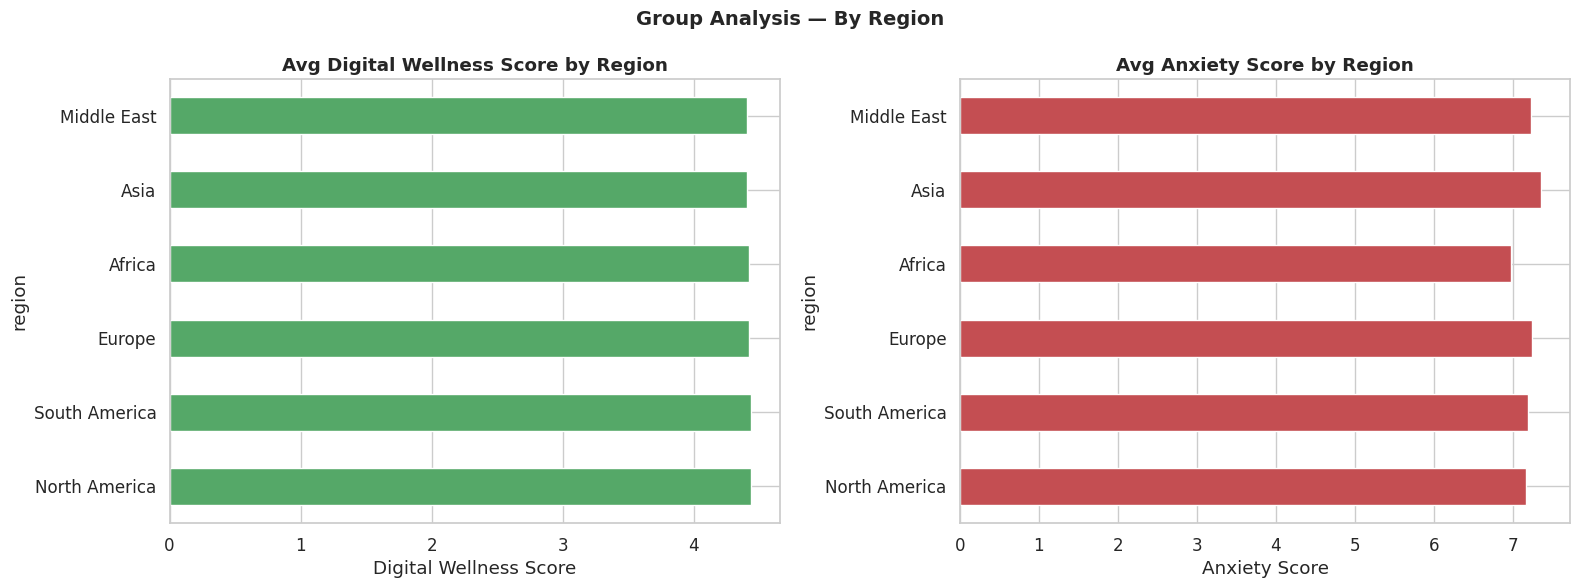


[3B] Metrics by Age Group...

Average Metrics by Age Group:
             device_hours_per_day  sleep_hours  anxiety_score  \
age_group                                                       
Teen                         7.22         7.03           7.24   
Young Adult                  7.25         7.16           7.22   
Adult                        7.31         7.31           7.21   
Mid Age                      7.44         7.49           7.15   
Senior                       7.56         7.70           7.19   

             productivity_score  digital_wellness_score  
age_group                                                
Teen                      65.40                    4.51  
Young Adult               65.22                    4.47  
Adult                     65.21                    4.41  
Mid Age                   65.23                    4.36  
Senior                    64.99                    4.30  


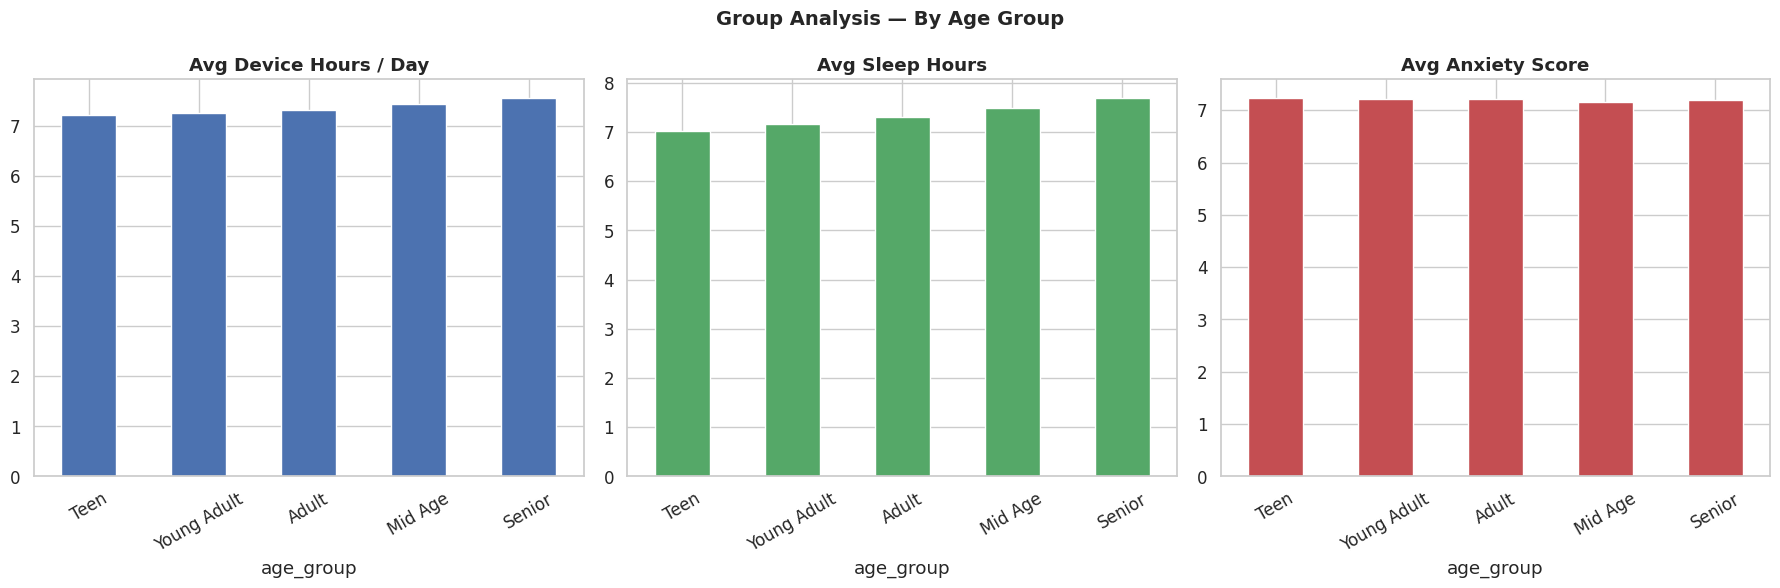


[3C] Device Behavior by Device Type...

Average Metrics by Device Type:
             device_hours_per_day  phone_unlocks  social_media_mins  \
device_type                                                           
Iphone                       7.37         145.29             155.88   
Tablet                       7.32         144.52             156.00   
Android                      7.31         144.40             156.70   
Laptop                       7.32         144.22             155.82   

             digital_dependence_score  digital_wellness_score  
device_type                                                    
Iphone                          36.94                    4.42  
Tablet                          36.71                    4.42  
Android                         36.69                    4.43  
Laptop                          36.66                    4.42  


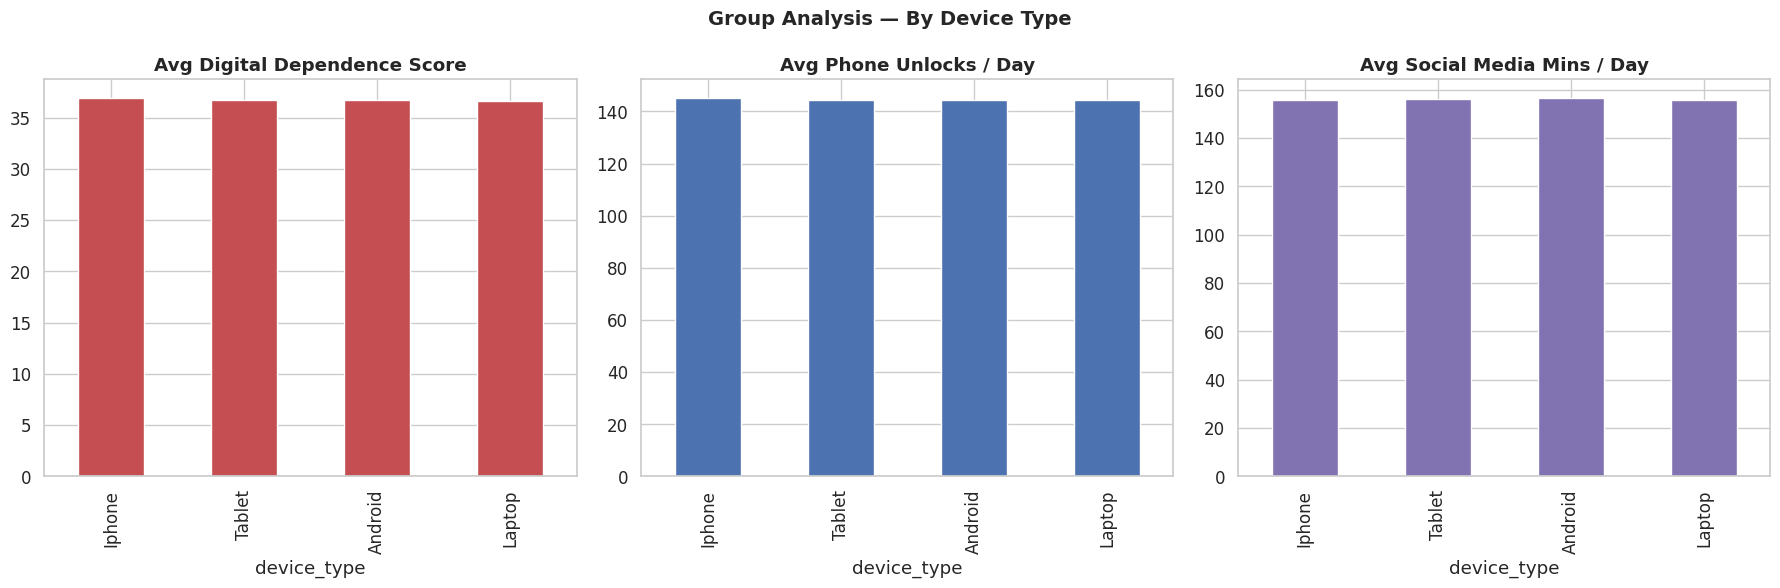


[3D] Metrics by Income Level...

Average Metrics by Income Level:
              digital_wellness_score  digital_dependence_score  \
income_level                                                     
Low                             4.42                     36.74   
Lower-Mid                       4.43                     36.61   
Upper-Mid                       4.41                     36.90   
High                            4.43                     36.79   

              productivity_score  happiness_score  anxiety_score  
income_level                                                      
Low                        65.19             6.40           7.22  
Lower-Mid                  65.19             6.43           7.19  
Upper-Mid                  65.31             6.38           7.20  
High                       65.19             6.42           7.19  


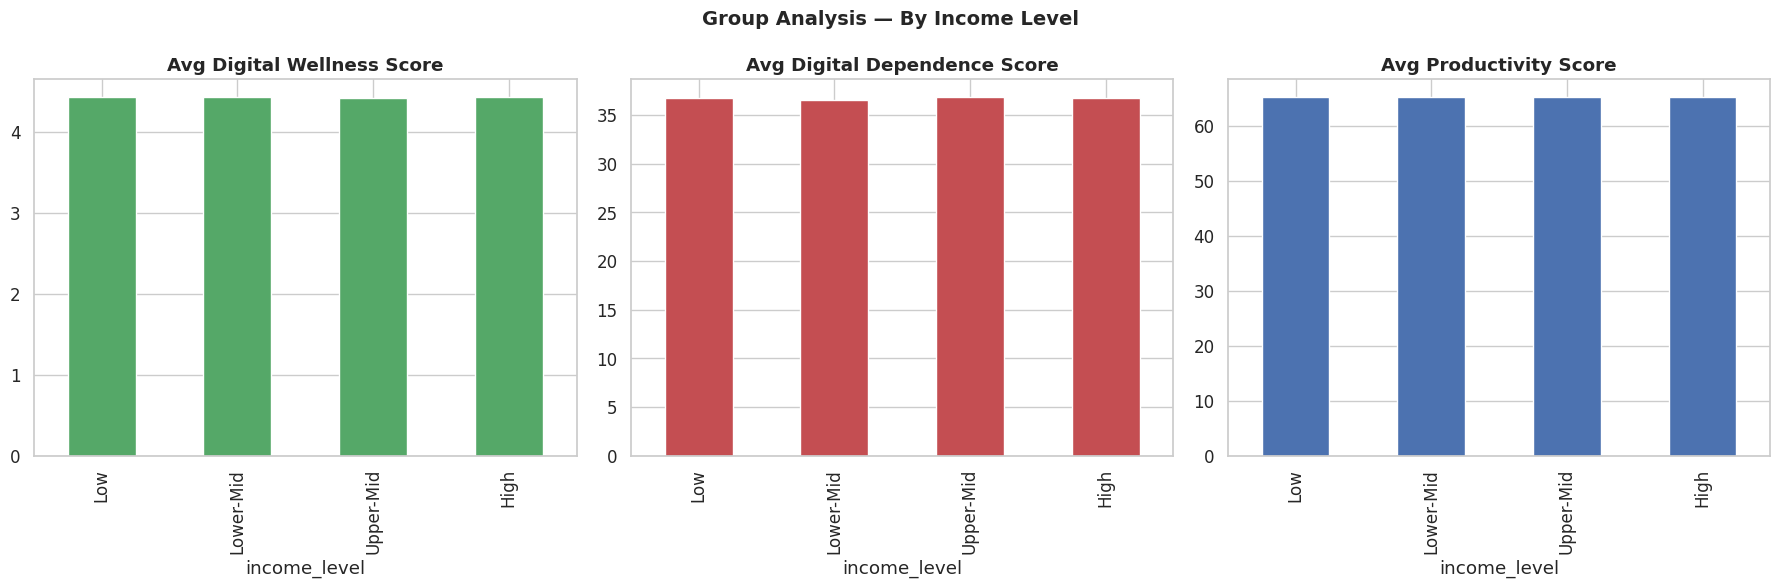


[3E] Heatmap — Mental Health Risk × Region...


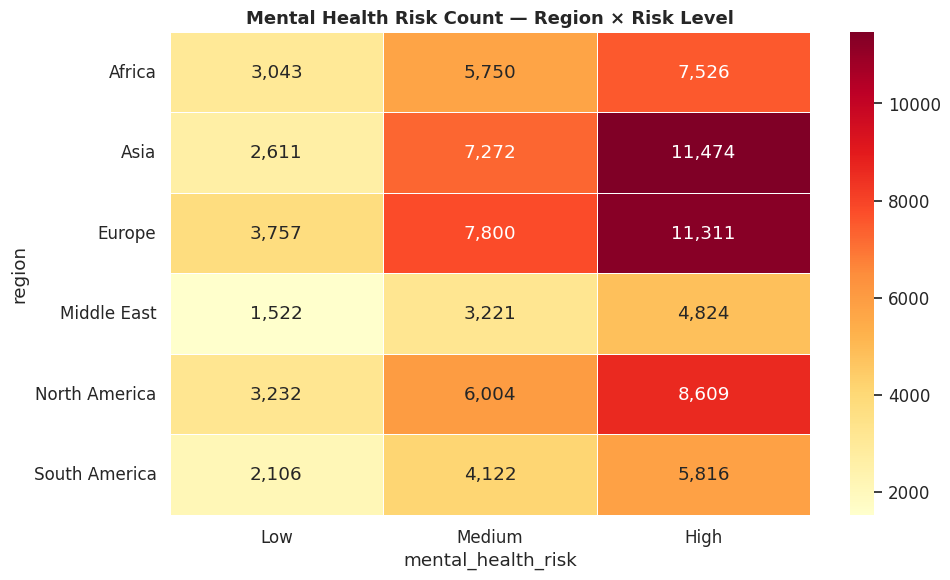


[3F] Heatmap — Productivity Category × Age Group...


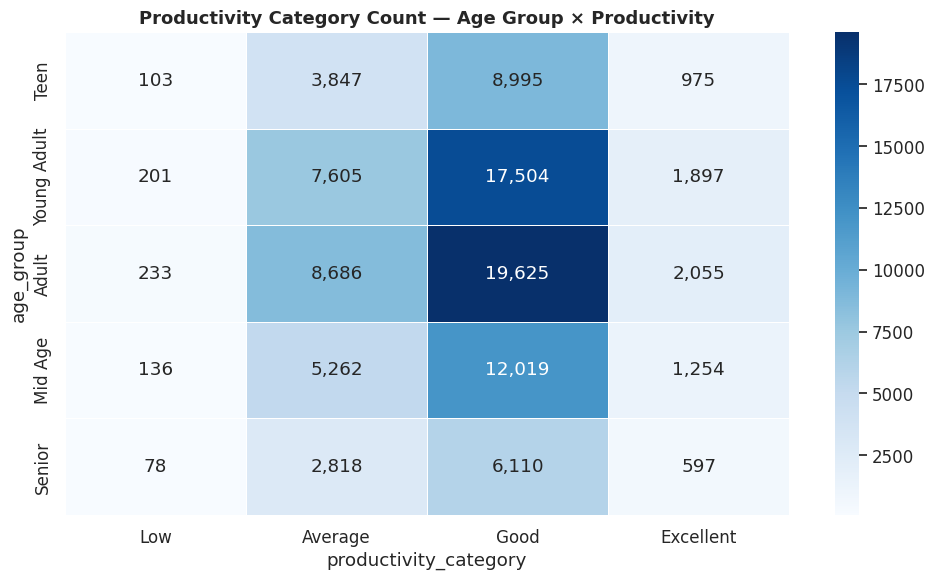

In [ ]:
print("\n" + "=" * 50)
print("SECTION 3 — GROUP ANALYSIS")
print("=" * 50)

# ── 3A. Wellness & Mental Health by Region ───────────────────

print("\n[3A] Wellness & Mental Health by Region...")

region_agg = (
    df.groupby("region")[
        [
            "digital_wellness_score",
            "anxiety_score",
            "depression_score",
            "happiness_score",
            "productivity_score"
        ]
    ]
    .mean()
    .round(2)
    .sort_values("digital_wellness_score", ascending=False)
)

print("\nAverage Metrics by Region:")
print(region_agg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_agg["digital_wellness_score"].plot(
    kind="barh",
    ax=axes[0],
    color="#55A868",
    edgecolor="white"
)

axes[0].set_title(
    "Avg Digital Wellness Score by Region",
    fontweight="bold"
)

axes[0].set_xlabel("Digital Wellness Score")

region_agg["anxiety_score"].plot(
    kind="barh",
    ax=axes[1],
    color="#C44E52",
    edgecolor="white"
)

axes[1].set_title(
    "Avg Anxiety Score by Region",
    fontweight="bold"
)

axes[1].set_xlabel("Anxiety Score")

fig.suptitle(
    "Group Analysis — By Region",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ── 3B. Screen Time, Sleep & Anxiety by Age Group ───────────

print("\n[3B] Metrics by Age Group...")

df["age_group"] = pd.Categorical(
    df["age_group"],
    categories=AGE_ORDER,
    ordered=True
)

age_agg = (
    df.groupby("age_group", observed=True)[
        [
            "device_hours_per_day",
            "sleep_hours",
            "anxiety_score",
            "productivity_score",
            "digital_wellness_score"
        ]
    ]
    .mean()
    .round(2)
)

print("\nAverage Metrics by Age Group:")
print(age_agg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

age_agg["device_hours_per_day"].plot(
    kind="bar",
    ax=axes[0],
    color="#4C72B0",
    edgecolor="white"
)

axes[0].set_title("Avg Device Hours / Day", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

age_agg["sleep_hours"].plot(
    kind="bar",
    ax=axes[1],
    color="#55A868",
    edgecolor="white"
)

axes[1].set_title("Avg Sleep Hours", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

age_agg["anxiety_score"].plot(
    kind="bar",
    ax=axes[2],
    color="#C44E52",
    edgecolor="white"
)

axes[2].set_title("Avg Anxiety Score", fontweight="bold")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle(
    "Group Analysis — By Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ── 3C. Device Behavior by Device Type ──────────────────────

print("\n[3C] Device Behavior by Device Type...")

device_agg = (
    df.groupby("device_type")[
        [
            "device_hours_per_day",
            "phone_unlocks",
            "social_media_mins",
            "digital_dependence_score",
            "digital_wellness_score"
        ]
    ]
    .mean()
    .round(2)
    .sort_values(
        "digital_dependence_score",
        ascending=False
    )
)

print("\nAverage Metrics by Device Type:")
print(device_agg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

device_agg["digital_dependence_score"].plot(
    kind="bar",
    ax=axes[0],
    color="#C44E52",
    edgecolor="white"
)

axes[0].set_title(
    "Avg Digital Dependence Score",
    fontweight="bold"
)

device_agg["phone_unlocks"].plot(
    kind="bar",
    ax=axes[1],
    color="#4C72B0",
    edgecolor="white"
)

axes[1].set_title(
    "Avg Phone Unlocks / Day",
    fontweight="bold"
)

device_agg["social_media_mins"].plot(
    kind="bar",
    ax=axes[2],
    color="#8172B2",
    edgecolor="white"
)

axes[2].set_title(
    "Avg Social Media Mins / Day",
    fontweight="bold"
)

fig.suptitle(
    "Group Analysis — By Device Type",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ── 3D. Wellness & Dependence by Income Level ───────────────

print("\n[3D] Metrics by Income Level...")

df["income_level"] = pd.Categorical(
    df["income_level"],
    categories=INCOME_ORDER,
    ordered=True
)

income_agg = (
    df.groupby("income_level", observed=True)[
        [
            "digital_wellness_score",
            "digital_dependence_score",
            "productivity_score",
            "happiness_score",
            "anxiety_score"
        ]
    ]
    .mean()
    .round(2)
)

print("\nAverage Metrics by Income Level:")
print(income_agg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

income_agg["digital_wellness_score"].plot(
    kind="bar",
    ax=axes[0],
    color="#55A868",
    edgecolor="white"
)

axes[0].set_title(
    "Avg Digital Wellness Score",
    fontweight="bold"
)

income_agg["digital_dependence_score"].plot(
    kind="bar",
    ax=axes[1],
    color="#C44E52",
    edgecolor="white"
)

axes[1].set_title(
    "Avg Digital Dependence Score",
    fontweight="bold"
)

income_agg["productivity_score"].plot(
    kind="bar",
    ax=axes[2],
    color="#4C72B0",
    edgecolor="white"
)

axes[2].set_title(
    "Avg Productivity Score",
    fontweight="bold"
)

fig.suptitle(
    "Group Analysis — By Income Level",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ── 3E. Heatmap — Mental Health Risk × Region ───────────────

print("\n[3E] Heatmap — Mental Health Risk × Region...")

mh_region = (
    df.groupby(
        ["region", "mental_health_risk"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=MH_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    mh_region,
    annot=True,
    fmt=",d",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title(
    "Mental Health Risk Count — Region × Risk Level",
    fontweight="bold",
    fontsize=13
)

plt.tight_layout()
plt.show()


# ── 3F. Heatmap — Productivity Category × Age Group ─────────

print("\n[3F] Heatmap — Productivity Category × Age Group...")

prod_age = (
    df.groupby(
        ["age_group", "productivity_category"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PROD_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    prod_age,
    annot=True,
    fmt=",d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title(
    "Productivity Category Count — Age Group × Productivity",
    fontweight="bold",
    fontsize=13
)

plt.tight_layout()
plt.show()

## SECTION 4 — OUTLIER DETECTION


SECTION 4 — OUTLIER DETECTION

[4A] IQR-based outlier detection...

Outlier Summary:
                  column  outlier_count  outlier_pct  lower_bound  upper_bound
           anxiety_score           7845         7.85        -3.20        16.00
       social_media_mins           6633         6.63      -144.50       411.50
   notifications_per_day           5496         5.50      -222.00       826.00
                     age           1762         1.76        -2.00        62.00
      productivity_score           1486         1.49        40.85        89.25
    device_hours_per_day           1071         1.07        -1.51        15.53
digital_dependence_score            994         0.99        -2.05        73.55
             sleep_hours            541         0.54         3.70        10.90
           phone_unlocks            502         0.50       -46.50       325.50
              study_mins            315         0.32      -137.00       343.00
        depression_score            231      

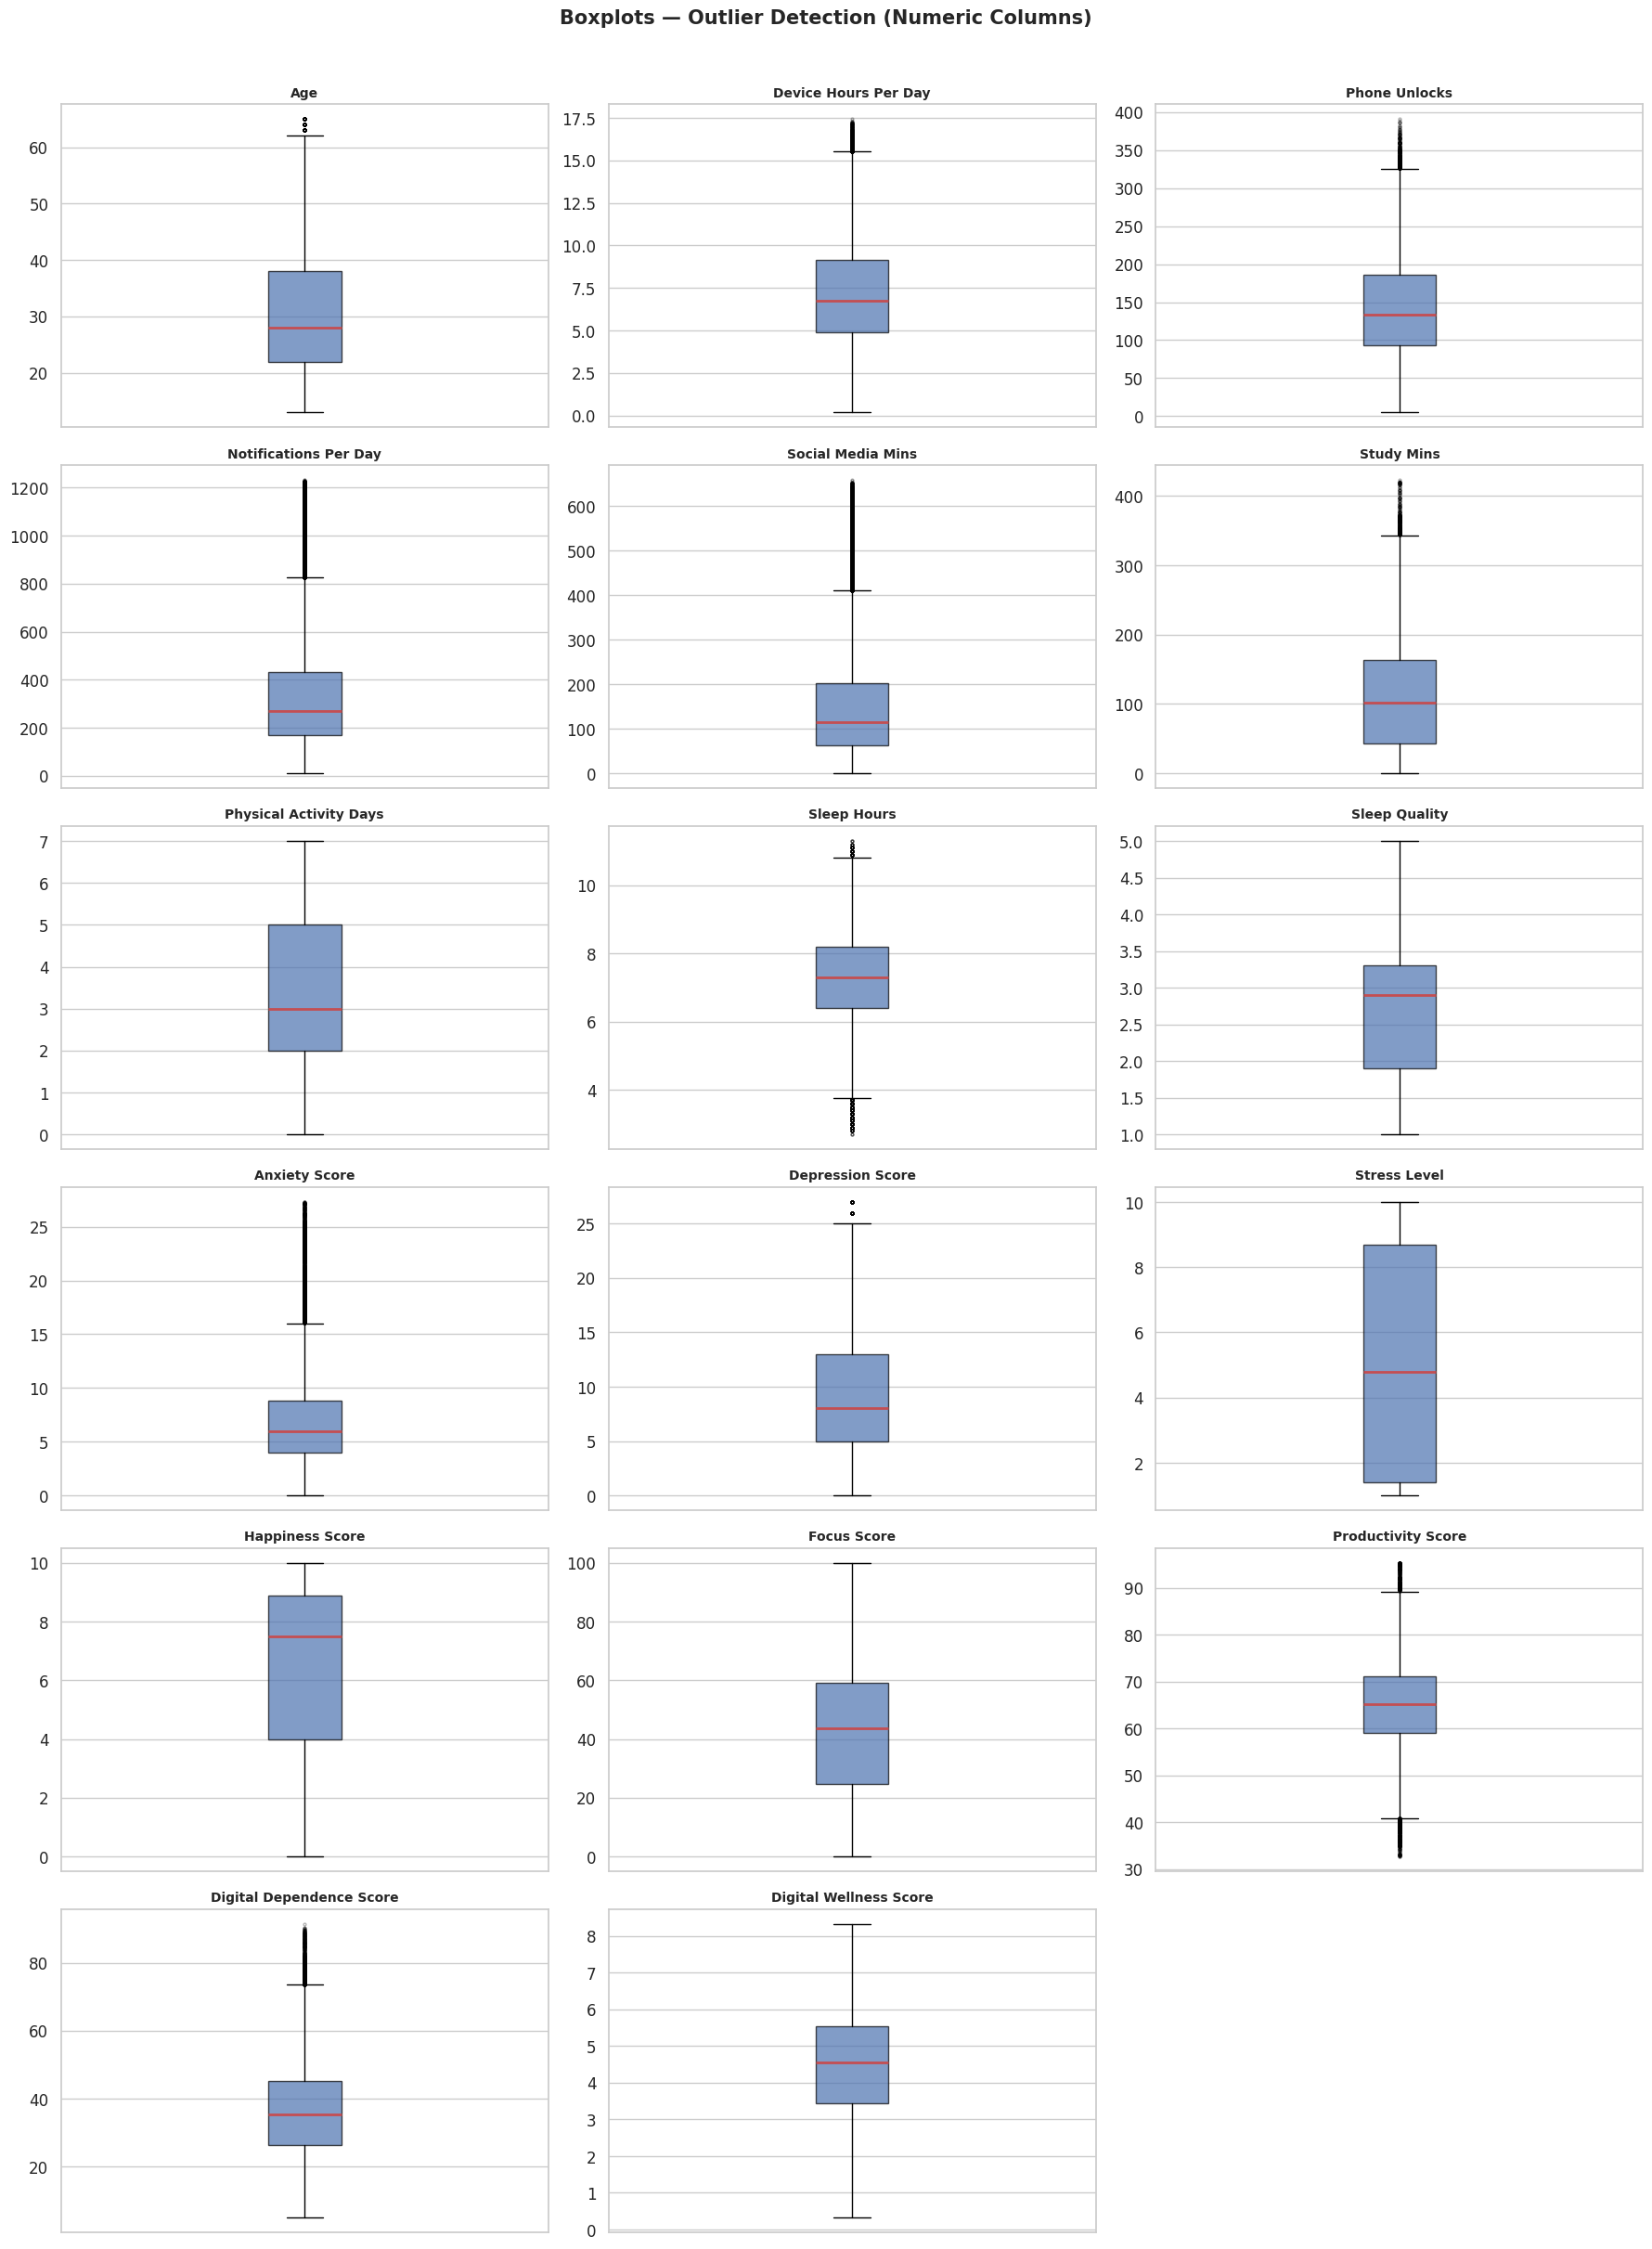


[4C] Top columns by outlier percentage...

Top Columns by Outlier Percentage:
               column  outlier_pct
        anxiety_score         7.85
    social_media_mins         6.63
notifications_per_day         5.50
                  age         1.76
   productivity_score         1.49
 device_hours_per_day         1.07


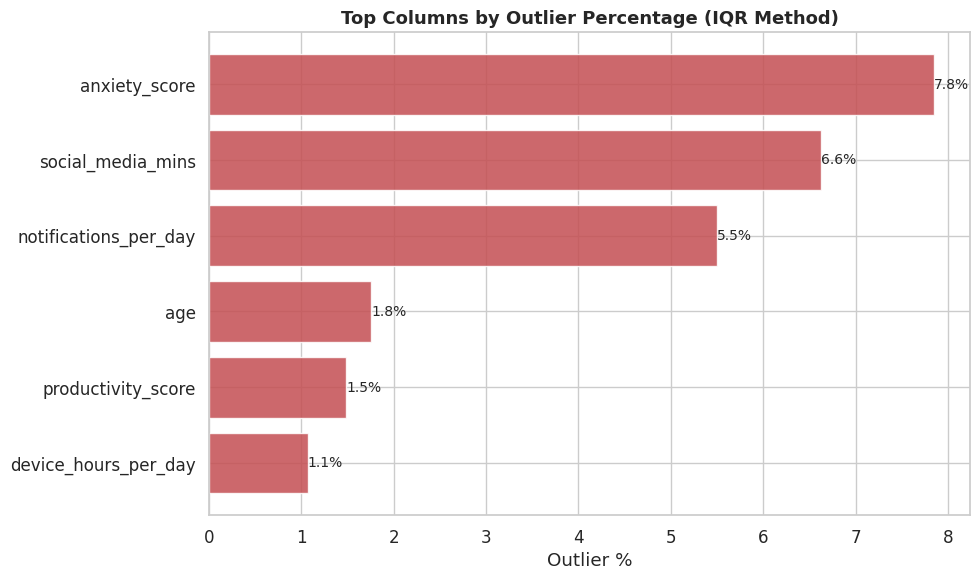

In [ ]:
print("\n" + "=" * 50)
print("SECTION 4 — OUTLIER DETECTION")
print("=" * 50)

# ── 4A. IQR-Based Outlier Summary ────────────────────────────

print("\n[4A] IQR-based outlier detection...")

outlier_summary = []

for col in NUMERIC_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": len(outliers),
        "outlier_pct": round(len(outliers) / len(df) * 100, 2),
    })

outlier_df = (
    pd.DataFrame(outlier_summary)
    .sort_values("outlier_count", ascending=False)
)

print("\nOutlier Summary:")
print(
    outlier_df[
        [
            "column",
            "outlier_count",
            "outlier_pct",
            "lower_bound",
            "upper_bound"
        ]
    ].to_string(index=False)
)


# ── 4B. Boxplots — all numeric columns ───────────────────────

print("\n[4B] Plotting boxplots for all numeric columns...")

n_cols = 3
n_rows = int(np.ceil(len(NUMERIC_COLS) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(
            facecolor="#4C72B0",
            alpha=0.7
        ),
        medianprops=dict(
            color="#C44E52",
            linewidth=2
        ),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3,
            color="#C44E52"
        ),
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=10,
        fontweight="bold"
    )

    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Boxplots — Outlier Detection (Numeric Columns)",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


# ── 4C. Columns with Highest Outlier % ──────────────────────

print("\n[4C] Top columns by outlier percentage...")

top_outliers = outlier_df.nlargest(
    6,
    "outlier_pct"
)

print("\nTop Columns by Outlier Percentage:")
print(
    top_outliers[
        ["column", "outlier_pct"]
    ].to_string(index=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_outliers["column"][::-1],
    top_outliers["outlier_pct"][::-1],
    color="#C44E52",
    edgecolor="white",
    alpha=0.85
)

ax.set_title(
    "Top Columns by Outlier Percentage (IQR Method)",
    fontweight="bold",
    fontsize=13
)

ax.set_xlabel("Outlier %")

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_width():.1f}%",
        (
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2
        ),
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## SECTION 5 — HIGH RISK ANALYSIS


SECTION 5 — HIGH RISK ANALYSIS

  High Risk users : 20,066 (20.1%)
  Normal users    : 79,934 (79.9%)

[5A] High Risk % by Region...
               total  high_risk  high_risk_pct
region                                        
South America  12044       2439          20.25
Asia           21357       4321          20.23
Europe         22868       4611          20.16
Middle East     9567       1925          20.12
Africa         16319       3275          20.07
North America  17845       3495          19.59


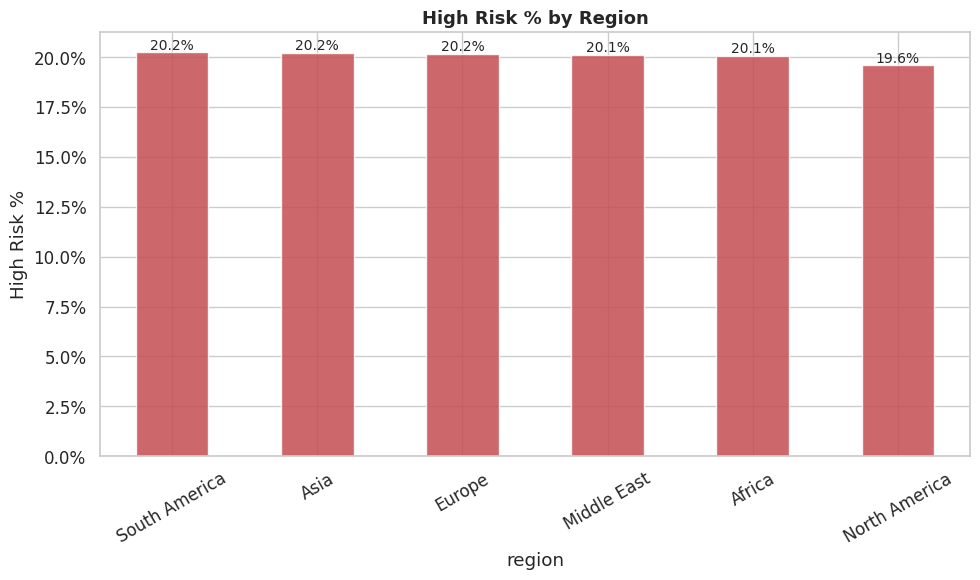


[5B] High Risk % by Age Group...
             total  high_risk  high_risk_pct
age_group                                   
Teen         13920       2730          19.61
Young Adult  27207       5407          19.87
Adult        30599       6209          20.29
Mid Age      18671       3811          20.41
Senior        9603       1909          19.88


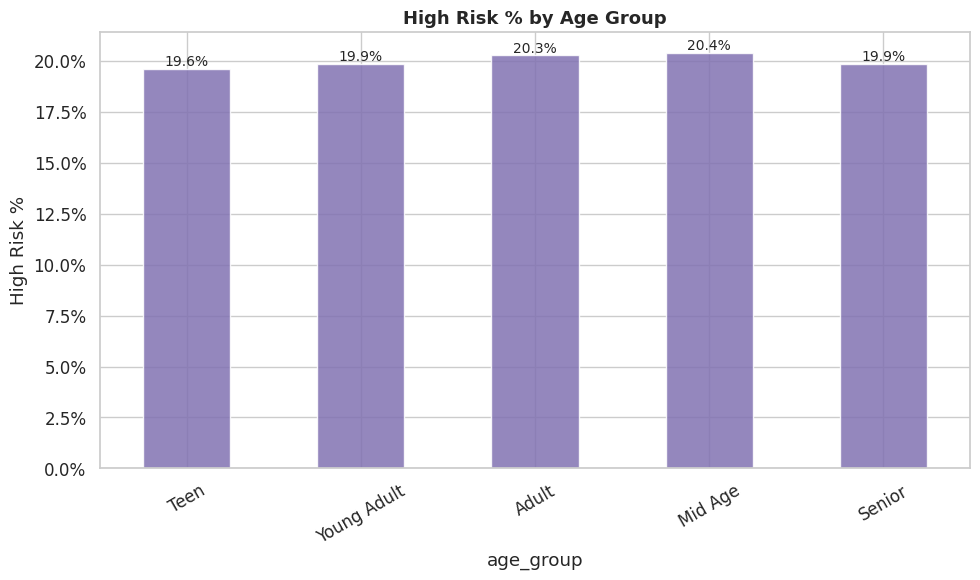


[5C] High Risk % by Device Type...
             total  high_risk  high_risk_pct
device_type                                 
Android      25721       5223          20.31
Iphone       23760       4776          20.10
Laptop       25278       5043          19.95
Tablet       25241       5024          19.90


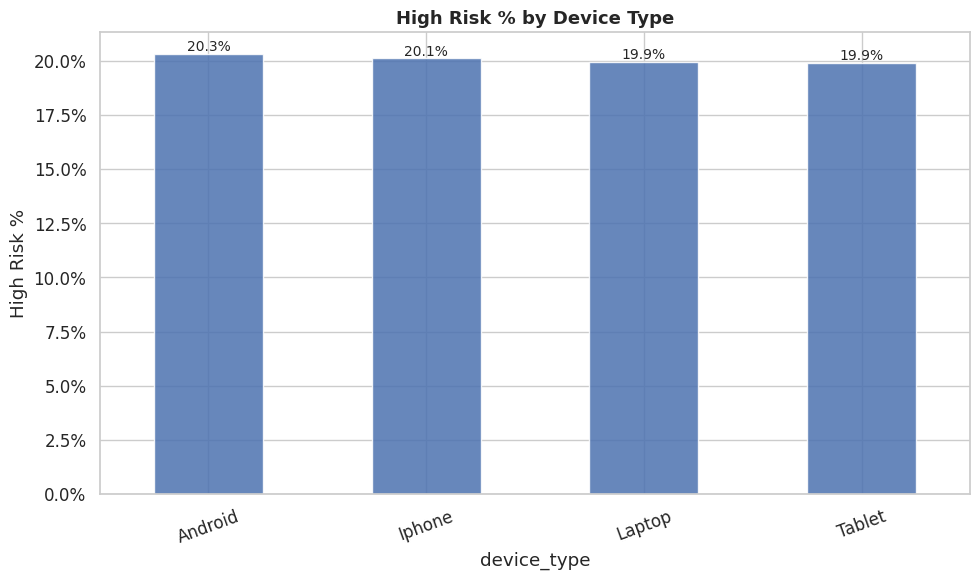


[5D] High Risk % by Income Level...
              total  high_risk  high_risk_pct
income_level                                 
Low           32458       6558          20.20
Lower-Mid     29866       6006          20.11
Upper-Mid     24159       4841          20.04
High          13517       2661          19.69


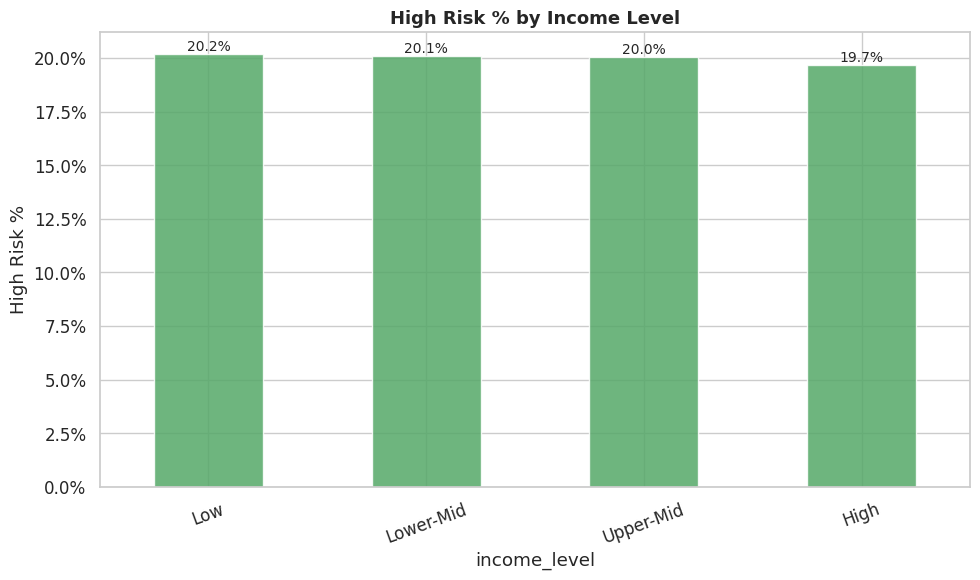


[5E] Mean comparison — High Risk vs Normal...
                          High Risk  Normal  Difference
anxiety_score                  9.84    6.54        3.30
depression_score              11.69    8.13        3.56
stress_level                   6.89    4.62        2.27
sleep_hours                    6.84    7.42       -0.58
happiness_score                5.16    6.72       -1.56
focus_score                   39.06   42.18       -3.12
productivity_score            65.42   65.17        0.25
digital_dependence_score      44.37   34.84        9.53
digital_wellness_score         3.79    4.58       -0.79


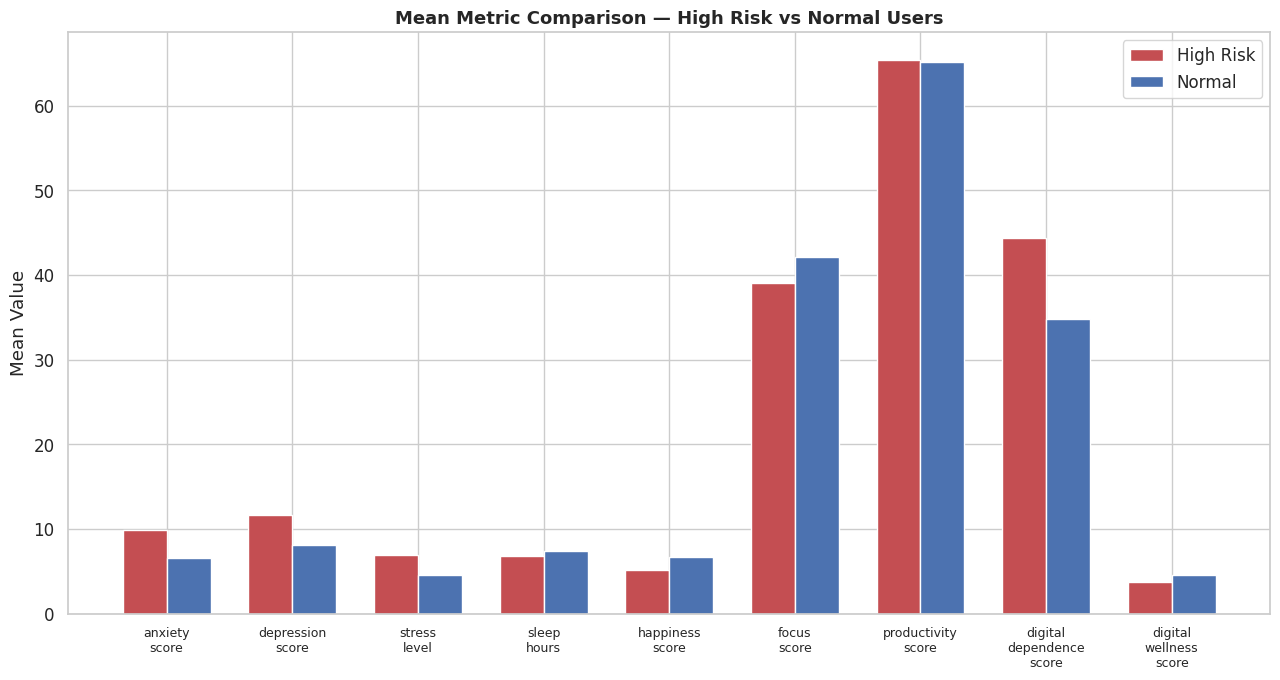


[5F] High Risk % by Daily Role & Education Level...


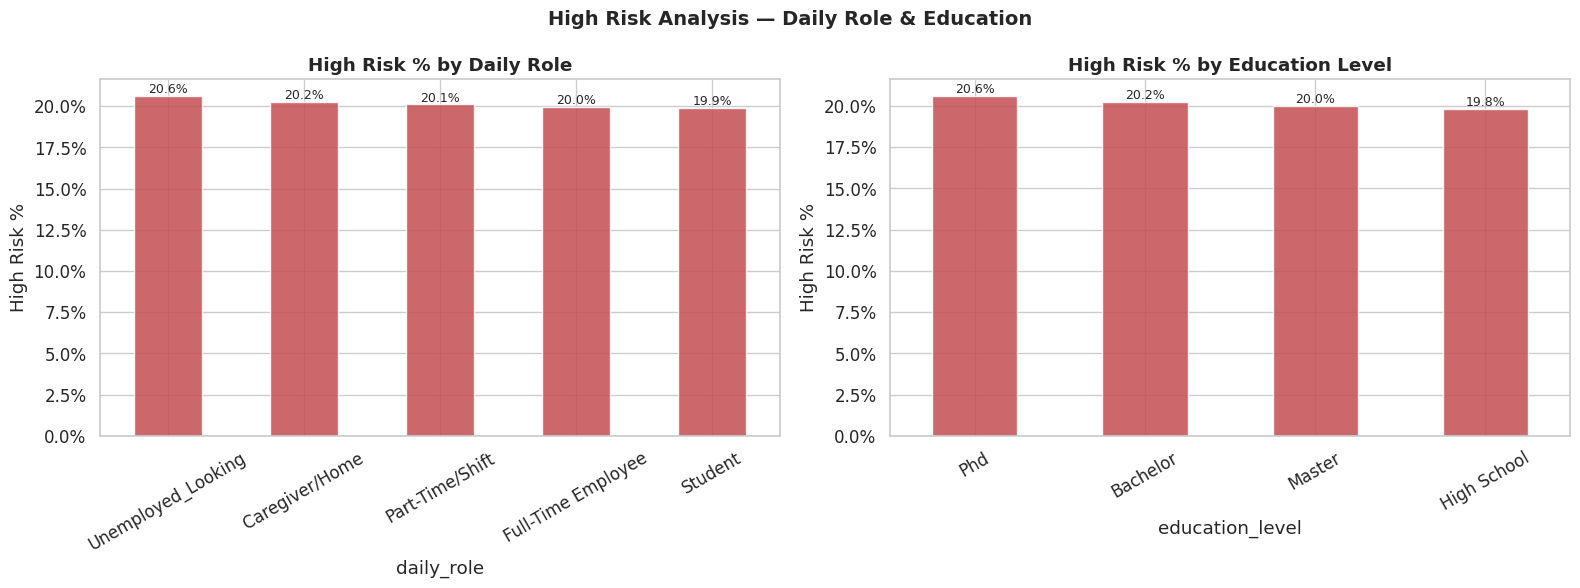

In [ ]:
print("\n" + "=" * 50)
print("SECTION 5 — HIGH RISK ANALYSIS")
print("=" * 50)

df_risk   = df[df["high_risk_flag"] == 1]
df_normal = df[df["high_risk_flag"] == 0]

print(f"\n  High Risk users : {len(df_risk):,} ({len(df_risk)/len(df)*100:.1f}%)")
print(f"  Normal users    : {len(df_normal):,} ({len(df_normal)/len(df)*100:.1f}%)")


# ── 5A. High Risk % by Region ────────────────────────────────

print("\n[5A] High Risk % by Region...")

hr_region = (
    df.groupby("region")["high_risk_flag"]
    .agg(total="count", high_risk="sum")
    .assign(high_risk_pct=lambda x: (x["high_risk"] / x["total"] * 100).round(2))
    .sort_values("high_risk_pct", ascending=False)
)

print(hr_region)

fig, ax = plt.subplots(figsize=(10, 6))

hr_region["high_risk_pct"].plot(
    kind="bar",
    ax=ax,
    color="#C44E52",
    edgecolor="white",
    alpha=0.85
)

ax.set_title("High Risk % by Region", fontweight="bold", fontsize=13)
ax.set_ylabel("High Risk %")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ── 5B. High Risk % by Age Group ────────────────────────────

print("\n[5B] High Risk % by Age Group...")

hr_age = (
    df.groupby("age_group", observed=True)["high_risk_flag"]
    .agg(total="count", high_risk="sum")
    .assign(high_risk_pct=lambda x: (x["high_risk"] / x["total"] * 100).round(2))
    .reindex(AGE_ORDER)
)

print(hr_age)

fig, ax = plt.subplots(figsize=(10, 6))

hr_age["high_risk_pct"].plot(
    kind="bar",
    ax=ax,
    color="#8172B2",
    edgecolor="white",
    alpha=0.85
)

ax.set_title("High Risk % by Age Group", fontweight="bold", fontsize=13)
ax.set_ylabel("High Risk %")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ── 5C. High Risk % by Device Type ──────────────────────────

print("\n[5C] High Risk % by Device Type...")

hr_device = (
    df.groupby("device_type")["high_risk_flag"]
    .agg(total="count", high_risk="sum")
    .assign(high_risk_pct=lambda x: (x["high_risk"] / x["total"] * 100).round(2))
    .sort_values("high_risk_pct", ascending=False)
)

print(hr_device)

fig, ax = plt.subplots(figsize=(10, 6))

hr_device["high_risk_pct"].plot(
    kind="bar",
    ax=ax,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.85
)

ax.set_title("High Risk % by Device Type", fontweight="bold", fontsize=13)
ax.set_ylabel("High Risk %")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ── 5D. High Risk % by Income Level ─────────────────────────

print("\n[5D] High Risk % by Income Level...")

hr_income = (
    df.groupby("income_level", observed=True)["high_risk_flag"]
    .agg(total="count", high_risk="sum")
    .assign(high_risk_pct=lambda x: (x["high_risk"] / x["total"] * 100).round(2))
    .reindex(INCOME_ORDER)
)

print(hr_income)

fig, ax = plt.subplots(figsize=(10, 6))

hr_income["high_risk_pct"].plot(
    kind="bar",
    ax=ax,
    color="#55A868",
    edgecolor="white",
    alpha=0.85
)

ax.set_title("High Risk % by Income Level", fontweight="bold", fontsize=13)
ax.set_ylabel("High Risk %")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ── 5E. Mean Comparison — High Risk vs Normal ───────────────

print("\n[5E] Mean comparison — High Risk vs Normal...")

compare_cols = [
    "anxiety_score",
    "depression_score",
    "stress_level",
    "sleep_hours",
    "happiness_score",
    "focus_score",
    "productivity_score",
    "digital_dependence_score",
    "digital_wellness_score",
]

comparison = pd.DataFrame({
    "High Risk": df_risk[compare_cols].mean().round(2),
    "Normal": df_normal[compare_cols].mean().round(2),
})

comparison["Difference"] = (
    comparison["High Risk"] - comparison["Normal"]
).round(2)

print(comparison)

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(compare_cols))
width = 0.35

ax.bar(
    x - width/2,
    comparison["High Risk"],
    width,
    label="High Risk",
    color="#C44E52"
)

ax.bar(
    x + width/2,
    comparison["Normal"],
    width,
    label="Normal",
    color="#4C72B0"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [c.replace("_", "\n") for c in compare_cols],
    fontsize=9
)

ax.set_title(
    "Mean Metric Comparison — High Risk vs Normal Users",
    fontweight="bold",
    fontsize=13
)

ax.set_ylabel("Mean Value")
ax.legend()

plt.tight_layout()
plt.show()


# ── 5F. High Risk Profile — Daily Role & Education ──────────

print("\n[5F] High Risk % by Daily Role & Education Level...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, group_col, title in zip(
    axes,
    ["daily_role", "education_level"],
    ["High Risk % by Daily Role", "High Risk % by Education Level"],
):

    hr_grp = (
        df.groupby(group_col)["high_risk_flag"]
        .agg(total="count", high_risk="sum")
        .assign(high_risk_pct=lambda x: (x["high_risk"] / x["total"] * 100).round(2))
        .sort_values("high_risk_pct", ascending=False)
    )

    hr_grp["high_risk_pct"].plot(
        kind="bar",
        ax=ax,
        color="#C44E52",
        edgecolor="white",
        alpha=0.85
    )

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("High Risk %")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    for bar in ax.patches:
        ax.annotate(
            f"{bar.get_height():.1f}%",
            (bar.get_x() + bar.get_width()/2, bar.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "High Risk Analysis — Daily Role & Education",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## FINAL — EDA SUMMARY REPORT


In [ ]:
print("\n" + "=" * 50)
print("FINAL — EDA SUMMARY REPORT")
print("=" * 50)

summary_rows = []

# Overall statistics
for col in NUMERIC_COLS:
    summary_rows.append({
        "Metric"   : col,
        "Mean"     : round(df[col].mean(), 2),
        "Median"   : round(df[col].median(), 2),
        "Std"      : round(df[col].std(), 2),
        "Min"      : round(df[col].min(), 2),
        "Max"      : round(df[col].max(), 2),
        "Skewness" : round(df[col].skew(), 2),
    })

summary_df = pd.DataFrame(summary_rows)

print("\nSummary Statistics:")
print(summary_df.to_string(index=False))

print("\n===== EDA COMPLETE =====")
print(f"Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Numeric Columns      : {len(NUMERIC_COLS)}")
print(f"Categorical Columns  : {len(CATEGORICAL_COLS)}")
print("\nAll visualizations displayed successfully in notebook output.")
print("========================")


FINAL — EDA SUMMARY REPORT

Summary Statistics:
                  Metric   Mean  Median    Std   Min     Max  Skewness
                     age  30.96   28.00  12.58 13.00   65.00      0.85
    device_hours_per_day   7.33    6.76   3.23  0.18   17.44      0.71
           phone_unlocks 144.60  134.00  68.73  5.00  391.00      0.63
   notifications_per_day 335.59  269.00 239.28 10.00 1232.00      1.64
       social_media_mins 156.10  116.00 134.68  0.00  659.00      1.57
              study_mins 108.33  102.00  79.41  0.00  423.00      0.49
  physical_activity_days   3.36    3.00   1.87  0.00    7.00      0.07
             sleep_hours   7.30    7.30   1.31  2.70   11.30     -0.17
           sleep_quality   2.70    2.90   1.10  1.00    5.00      0.04
           anxiety_score   7.20    6.00   5.08  0.00   27.30      1.56
        depression_score   8.84    8.00   5.73  0.00   27.00      0.48
            stress_level   5.08    4.80   3.38  1.00   10.00      0.22
         happiness_score   6